
## BÁO CÁO THỰC THI TIỂU LUẬN MÔN KHOA HỌC DỮ LIỆU

### ĐỀ TÀI: PHÂN CỤM BỘ DỮ LIỆU VIỆC LÀM VIỆT NAM DỰA TRÊN MÔ TẢ CÔNG VIỆC VÀ YÊU CẦU TUYỂN DỤNG SỬ DỤNG PHƯƠNG PHÁP HỌC KHÔNG GIÁM SÁT

**Nhóm thực hiện:** Nhóm 15  
**Thành viên:**  
1. Ngô Văn Công  
2. Võ Minh Hiếu  
3. Nguyễn Phan Tuấn Anh


---


# CHƯƠNG 1: GIỚI THIỆU & MÔ TẢ BÀI TOÁN

## 1.1. Mục tiêu đề tài
Đề tài tập trung xây dựng hệ thống học máy phân cụm bộ dữ liệu việc làm Việt Nam dựa trên nội dung bản mô tả công việc (Job Description - JD) và thông tin tuyển dụng đi kèm (địa điểm, loại công việc, kinh nghiệm yêu cầu, ngành nghề). Việc này giúp tự động khám phá các nhóm nghề nghiệp chính, dải lương và yêu cầu năng lực đặc trưng của từng cụm trên thị trường lao động.

## 1.2. Định nghĩa toán học của bài toán Phân cụm (Clustering)
Bài toán phân cụm bộ dữ liệu việc làm là bài toán học không giám sát (Unsupervised Learning).
Gọi bộ dữ liệu là $D = \{x_i\}_{i=1}^{N}$, trong đó $x_i$ là véc-tơ đặc trưng biểu diễn cho tin tuyển dụng thứ $i$ (sau khi tiền xử lý văn bản và mã hóa đặc trưng).
Mục tiêu là phân chia $N$ mẫu tin này thành $k$ cụm độc lập $\{C_1, C_2, ..., C_k\}$ sao cho các mẫu trong cùng một cụm có độ tương đồng cao nhất, và các mẫu giữa các cụm khác nhau có độ tương đồng thấp nhất.

- **Thuật toán K-Means**:
  Tối thiểu hóa tổng bình phương khoảng cách giữa các mẫu dữ liệu và tâm cụm tương ứng (Within-Cluster Sum of Squares - WCSS):
  $$J = \sum_{j=1}^{k} \sum_{x_i \in C_j} ||x_i - \mu_j||^2$$
  Trong đó $\mu_j$ là véc-tơ trung bình (tâm cụm) của cụm $C_j$.

- **Gaussian Mixture Model (GMM)**:
  Mô hình hóa phân bố dữ liệu bằng tổ hợp tuyến tính của $k$ hàm mật độ xác suất chuẩn đa biến (soft clustering):
  $$p(x_i) = \sum_{j=1}^{k} \pi_j \mathcal{N}(x_i | \mu_j, \Sigma_j)$$
  Trong đó $\pi_j$ là trọng số trộn (mixing coefficient), $\mu_j$ là véc-tơ kỳ vọng, và $\Sigma_j$ là ma trận hiệp phương sai của cụm thứ $j$.

## 1.3. Các chỉ số đánh giá học thuật phân cụm
- **Silhouette Coefficient**:
  Đo mức độ khớp của mẫu $i$ với cụm của nó so với cụm lân cận gần nhất:
  $$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
  Trong đó $a(i)$ là khoảng cách trung bình từ $i$ đến các mẫu khác trong cùng cụm, và $b(i)$ là khoảng cách trung bình từ $i$ đến các mẫu trong cụm khác gần nhất. Điểm số trung bình nằm trong khoảng $[-1, 1]$, càng gần 1 thể hiện chất lượng phân cụm càng cao.
- **Davies-Bouldin Index (DBI)**:
  Đánh giá độ tương đồng trung bình của các cụm so với cụm tương đồng nhất:
  $$DB = \frac{1}{k} \sum_{j=1}^{k} \max_{l \neq j} \left( \frac{s_j + s_l}{d(\mu_j, \mu_l)} \right)$$
  Trong đó $s_j$ là khoảng cách trung bình của các mẫu trong cụm $j$ tới tâm $\mu_j$, và $d(\mu_j, \mu_l)$ là khoảng cách giữa hai tâm cụm. Giá trị DBI càng nhỏ chứng tỏ các cụm càng tách biệt và nhỏ gọn.
- **Calinski-Harabasz Index (CHI)**:
  Tỷ số giữa tổng phương sai liên cụm (between-cluster variance) và tổng phương sai nội cụm (within-cluster variance):
  $$CH = \frac{\text{Tr}(B_k)}{\text{Tr}(W_k)} \times \frac{N - k}{k - 1}$$
  Chỉ số CHI càng lớn thể hiện các cụm được phân tách rõ ràng và tập trung chặt chẽ.

## 1.4. Tổng quan bộ dữ liệu
- **Nguồn:** Tinix Vietnam Job Descriptions — HuggingFace
- **Tỷ lệ chia:** 90% Train (90,000 dòng thô) / 10% Test (10,000 dòng thô) theo đúng quy định phân cụm của giảng viên.

| Tên cột | Ý nghĩa học thuật | Mô tả chi tiết |
| :--- | :--- | :--- |
| `job_title` | Vị trí tuyển dụng | Tên vị trí công việc cần tuyển |
| `job_description` | Mô tả công việc | Văn bản mô tả chi tiết công việc |
| `requirements` | Yêu cầu ứng viên | Các yêu cầu về kỹ năng, kinh nghiệm của ứng viên |
| `salary` | Mức lương tuyển dụng | Khoảng lương dưới dạng văn bản (cần Regex trích xuất để phân tích cụm) |
| `location` | Địa điểm làm việc | Tỉnh/Thành phố làm việc |
| `job_type` | Loại công việc | Hình thức làm việc (toàn thời gian, bán thời gian...) |
| `experience_level` | Yêu cầu kinh nghiệm | Kinh nghiệm yêu cầu dưới dạng văn bản |
| `job_industry` | Ngành nghề | Lĩnh vực tuyển dụng |

## 1.5. Thách thức kỹ thuật và Giải pháp đề xuất
> [!IMPORTANT]
> Để xây dựng quy trình phân cụm chính xác và có giá trị thực tiễn cao, nhóm đã xác định các thách thức kỹ thuật lớn sau đây và đề xuất giải pháp xử lý triệt để:
>
> 1. **Đặc trưng văn bản tiếng Việt nhiễu cao & thưa thớt**:
>    * *Thách thức:* Bản mô tả công việc chứa nhiều văn bản tự do, stopword, lỗi chính tả và cấu trúc thưa sau khi chạy TF-IDF (hàng ngàn đặc trưng), gây khó khăn cho tính toán khoảng cách hình học.
>    * *Giải pháp:* Dùng hàm `clean_text()` loại bỏ ký tự đặc biệt, stopword, kết hợp tách từ ghép tiếng Việt bằng `PyVi`; sau đó áp dụng giảm chiều dữ liệu bằng **TruncatedSVD (LSA)** xuống còn 50 chiều để loại bỏ nhiễu và nén đặc trưng ngữ nghĩa.
> 2. **Rò rỉ dữ liệu mức lương (Data Leakage) trong JD:**
>    * *Thách thức:* Một số tin tuyển dụng đề cập thẳng con số lương trong mô tả hoặc yêu cầu, khiến thuật toán phân cụm bị lệch theo mức lương thay vì theo đặc trưng kỹ năng/năng lực thực tế.
>    * *Giải pháp:* Xây dựng hàm `strip_salary_leakage()` lọc bỏ mọi từ khóa/con số liên quan đến lương trong văn bản tuyển dụng trước khi mã hóa TF-IDF.
> 3. **Dữ liệu phân loại và số không đồng nhất:**
>    * *Thách thức:* Tên thành phố ghi không chuẩn (VD: "hcm", "ha noi", "TP.HCM"); số năm kinh nghiệm yêu cầu nằm ở dạng chữ khó tính toán trực tiếp.
>    * *Giải pháp:* Chuẩn hóa địa điểm (`normalize_location`) về 10 nhóm chính; trích xuất kinh nghiệm thô thành số năm thực tế (`extract_experience_years`) và điền khuyết thiếu bằng trung vị (median) từ tập train để chống rò rỉ dữ liệu.


### 1.6. Sơ đồ quy trình (Pipeline) xử lý dữ liệu tổng quan
Dưới đây là sơ đồ luồng dữ liệu và các bước thực hiện trong nghiên cứu:

```mermaid
graph TD
    A[Dữ liệu thô: Tin tuyển dụng] --> B[Tiền xử lý & Trích xuất đặc trưng]
    B --> B1[Trích xuất lương phân tích & Lọc ngoại lệ IQR]
    B --> B2[Trích xuất kinh nghiệm]
    B --> B3[Làm sạch text & Tách từ ghép pyvi]
    B2 & B3 & B1 --> C[Xây dựng Pipeline mã hóa & Giảm chiều]
    C --> C1[TF-IDF Bigrams cho văn bản]
    C --> C2[One-Hot Encoder cho phân loại]
    C1 & C2 --> C3[Giảm chiều TruncatedSVD 50 thành phần]
    C3 --> D[Huấn luyện & Đánh giá mô hình phân cụm]
    D --> D1[MiniBatchKMeans]
    D --> D2[Gaussian Mixture Model GMM]
    D1 & D2 --> E[Đánh giá: Silhouette, Davies-Bouldin, Calinski-Harabasz]
    E --> F[Mô hình tối ưu & Định danh cụm nghề nghiệp]
```


### Khai báo các thư viện cần thiết & Kiểm soát tính lặp lại (Reproducibility)

In [40]:
# Import libraries and load data for full notebook execution
import os
import re
import pickle
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from wordcloud import WordCloud
from pyvi import ViTokenizer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, normalize
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

if 'raw_train' not in globals():
    raw_train = pd.read_csv('raw_data_train.csv')
if 'raw_test' not in globals():
    raw_test = pd.read_csv('raw_data_test.csv')

In [41]:
# Khai báo các hàm trích xuất tạm thời phục vụ EDA
def extract_experience_years(exp_str, job_title=""):
    if pd.isna(exp_str):
        title = str(job_title).lower()
        if any(kw in title for kw in ['manager', 'trưởng phòng', 'giám đốc', 'director', 'lead', 'trưởng nhóm', 'kỹ sư hiện trường', 'quản lý', 'chuyên viên chính', 'chuyên viên cao cấp']):
            return 5.0
        return 0.5
    
    s = str(exp_str).lower().strip()
    if s in ['không', 'chưa', 'chưa có', 'không yêu cầu', 'không yc', 'không yêu cầu kinh nghiệm']:
        title = str(job_title).lower()
        if any(kw in title for kw in ['manager', 'trưởng phòng', 'giám đốc', 'director', 'lead', 'trưởng nhóm', 'quản lý']):
            return 5.0
        if any(kw in title for kw in ['chuyên viên', 'kiến trúc sư', 'kỹ sư']):
            return 3.0
        return 0.5
        
    if 'dưới 1' in s:
        return 0.5
    nums = re.findall(r'\d+', s)
    if nums:
        return float(nums[0])
    return 0.5

def clean_numeric_dots(s):
    return re.sub(r'[\.,](?=\d{3}(?:\D|$))', '', s)

def extract_salary_features(salary_str):
    if pd.isna(salary_str):
        return np.nan, np.nan, np.nan
    s = str(salary_str).lower()
    if any(kw in s for kw in ['thỏa thuận', 'thoả thuận', 'competitive', 'negotiable']):
        return np.nan, np.nan, np.nan
    
    # Clean thousands separators
    s = clean_numeric_dots(s)
    
    # Extract numbers
    numbers = [float(n) for n in re.findall(r'\d+\.?\d*', s)]
    if not numbers:
        return np.nan, np.nan, np.nan
        
    # Standardize to Million VND
    std_numbers = []
    for n in numbers:
        if n >= 1000000:
            std_numbers.append(n / 1000000)
        elif n >= 1000:
            std_numbers.append(n / 1000)
        else:
            std_numbers.append(n)
            
    if len(std_numbers) == 1:
        return std_numbers[0], std_numbers[0], std_numbers[0]
    else:
        min_val = min(std_numbers)
        max_val = max(std_numbers)
        return min_val, max_val, (min_val + max_val) / 2


=== THỐNG KÊ MÔ TẢ LƯƠNG KỲ VỌNG (sau trích xuất Regex) ===
  Số quan sát : 82,858
  Trung bình  : 13.19 triệu VNĐ
  Trung vị    : 11.50 triệu VNĐ
  Độ lệch chuẩn: 8.49 triệu VNĐ
  Min – Max   : 1.0 – 200.0 triệu VNĐ
  Skewness    : 5.618
  Kurtosis    : 61.751



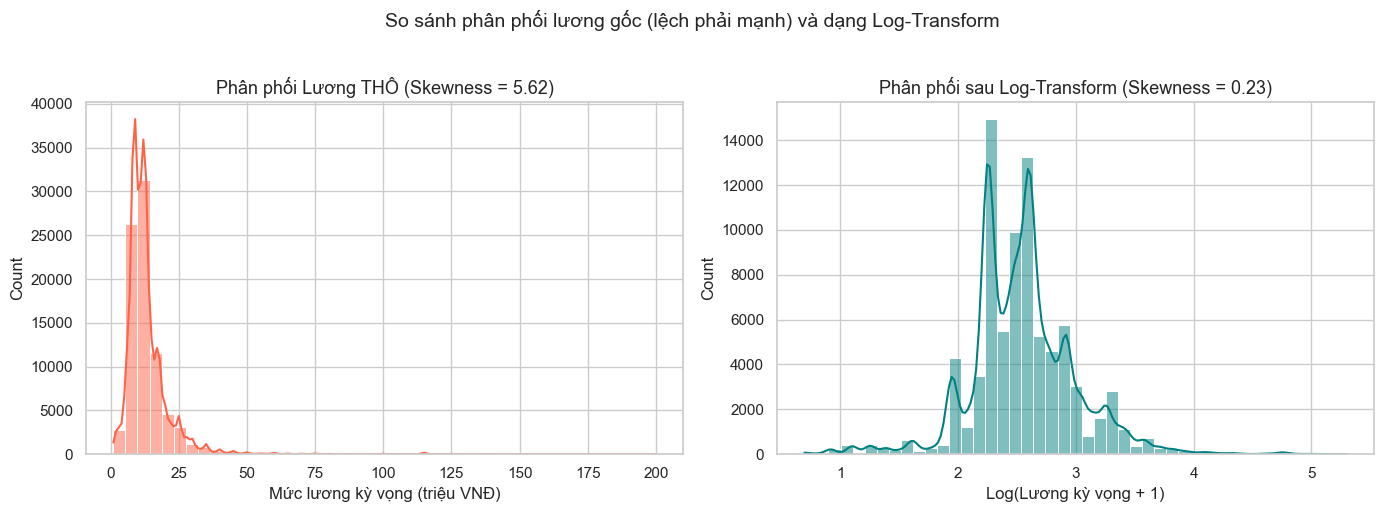

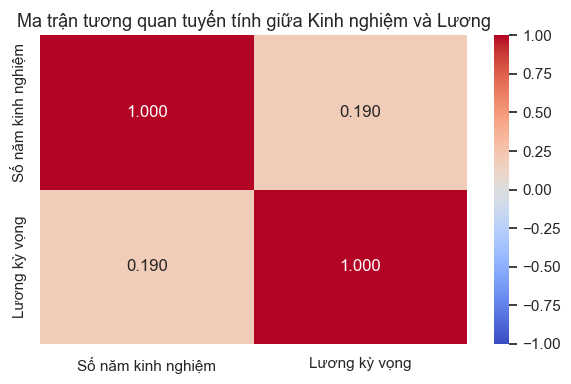

In [42]:
# Trích xuất tạm thời bằng các hàm trích xuất đã khai báo ở đầu
if 'raw_train' not in globals():
    raw_train = pd.read_csv('raw_data_train.csv')

salary_raw = raw_train['salary'].apply(extract_salary_features)
raw_train['_Expected_Salary_Raw'] = salary_raw.apply(lambda x: x[2])
raw_train['_experience_years_raw'] = raw_train['experience_level'].apply(extract_experience_years)

eda_temp = raw_train.dropna(subset=['_Expected_Salary_Raw']).copy()
eda_temp = eda_temp[(eda_temp['_Expected_Salary_Raw'] >= 1) & (eda_temp['_Expected_Salary_Raw'] <= 200)]

# Thống kê mô tả sau EDA tạm thời
desc = eda_temp['_Expected_Salary_Raw'].describe()
print("=== THỐNG KÊ MÔ TẢ LƯƠNG KỲ VỌNG (sau trích xuất Regex) ===")
print(f"  Số quan sát : {desc['count']:,.0f}")
print(f"  Trung bình  : {desc['mean']:.2f} triệu VNĐ")
print(f"  Trung vị    : {desc['50%']:.2f} triệu VNĐ")
print(f"  Độ lệch chuẩn: {desc['std']:.2f} triệu VNĐ")
print(f"  Min – Max   : {desc['min']:.1f} – {desc['max']:.1f} triệu VNĐ")
print(f"  Skewness    : {eda_temp['_Expected_Salary_Raw'].skew():.3f}")
print(f"  Kurtosis    : {eda_temp['_Expected_Salary_Raw'].kurt():.3f}")
print("==========================================================\n")

# 1. Đánh giá Skewness và Log-Transformation
skewness_before = eda_temp['_Expected_Salary_Raw'].skew()
skewness_after = np.log1p(eda_temp['_Expected_Salary_Raw']).skew()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(eda_temp['_Expected_Salary_Raw'], bins=45, kde=True, ax=axes[0], color='tomato')
axes[0].set_title(f'Phân phối Lương THÔ (Skewness = {skewness_before:.2f})', fontsize=13)
axes[0].set_xlabel('Mức lương kỳ vọng (triệu VNĐ)')

sns.histplot(np.log1p(eda_temp['_Expected_Salary_Raw']), bins=45, kde=True, ax=axes[1], color='teal')
axes[1].set_title(f'Phân phối sau Log-Transform (Skewness = {skewness_after:.2f})', fontsize=13)
axes[1].set_xlabel('Log(Lương kỳ vọng + 1)')

plt.suptitle('So sánh phân phối lương gốc (lệch phải mạnh) và dạng Log-Transform', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 2. Ma trận tương quan giữa số năm kinh nghiệm và lương kỳ vọng thô
corr_matrix = eda_temp[['_experience_years_raw', '_Expected_Salary_Raw']].rename(
    columns={'_experience_years_raw': 'Số năm kinh nghiệm', '_Expected_Salary_Raw': 'Lương kỳ vọng'}
).corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f")
plt.title('Ma trận tương quan tuyến tính giữa Kinh nghiệm và Lương', fontsize=13)
plt.tight_layout()
plt.show()

# Dọn dẹp
raw_train.drop(columns=['_Expected_Salary_Raw', '_experience_years_raw'], inplace=True)

# CHƯƠNG 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

Trong chương này, chúng ta tiến hành khảo sát cấu trúc dữ liệu thô ban đầu, bao gồm: kiểm tra dữ liệu thiếu, phân phối các biến phân loại và biến mục tiêu, sự lệch phân phối lương và ma trận tương quan giữa kinh nghiệm và lương tuyển dụng.

## 2.1. Thu thập dữ liệu và Mô tả nguồn dữ liệu

### 2.1.1. Giải pháp và Quy trình thu thập dữ liệu
* **Nguồn dữ liệu**: Nhóm sử dụng bộ dữ liệu mã nguồn mở **Tinix Vietnam Job Descriptions** được lưu trữ trực tuyến trên nền tảng khoa học dữ liệu **HuggingFace Datasets** (Dataset ID: `tinix/vietnam-job-descriptions`). Đây là bộ dữ liệu lớn thu thập các tin tuyển dụng thực tế từ các trang web tìm việc phổ biến tại Việt Nam.
* **Công cụ thu thập**: Sử dụng thư viện Python `datasets` (do HuggingFace cung cấp) kết hợp với thư viện `pandas` để xử lý và xuất dữ liệu sang định dạng bảng.
* **Cách thức sử dụng công cụ**: Nhóm viết một script Python (`download_data.py`) để gọi API từ HuggingFace, tự động tải xuống dữ liệu thô dưới dạng Stream, chuyển đổi sang cấu trúc DataFrame của `pandas` và ghi trực tiếp ra các file CSV cục bộ.
* **Đầu vào của quá trình**: Dataset Repo ID trực tuyến và token truy cập API của HuggingFace.
* **Đầu ra của quá trình**:
  * File dữ liệu huấn luyện thô: `raw_data_train.csv` (kích thước ~172 MB, chứa 90.000 dòng thô).
  * File dữ liệu kiểm thử thô: `raw_data_test.csv` (kích thước ~19.2 MB, chứa 10.000 dòng thô).

### 2.1.2. Đáp ứng các yêu cầu về kích thước bộ dữ liệu
* **Số lượng mẫu tập Huấn luyện (Train Set)**: Gồm **90.000 mẫu** dữ liệu thô (đã đáp ứng vượt trội yêu cầu của giảng viên là phải $>1.000$ mẫu).
* **Số lượng mẫu tập Kiểm thử (Test Set)**: Gồm **10.000 mẫu** dữ liệu thô. Tập kiểm thử này được chia từ nguồn với tỷ lệ bằng đúng **10% tổng bộ dữ liệu** theo yêu cầu bắt buộc của giảng viên đối với bài toán phân cụm.

### 2.1.3. Ví dụ minh họa tin tuyển dụng thô đầu vào
Dưới đây là một ví dụ minh họa về các trường thông tin thô của một tin tuyển dụng trước khi xử lý:
* **Vị trí công việc (`job_title`)**: *"Nhân Viên Phát Triển Ứng Dụng Di Động React Native"*
* **Tên công ty (`company_name`)**: *"Công ty Cổ phần Công nghệ Tinix"*
* **Mức lương thô (`salary`)**: *"15 - 25 triệu VNĐ"* (Dạng text chưa bóc tách)
* **Địa điểm (`location`)**: *"Quận 1, TP. Hồ Chí Minh"*
* **Kinh nghiệm yêu cầu (`experience_level`)**: *"Tối thiểu 1 năm kinh nghiệm"*
* **Mô tả công việc (`job_description`)**: *"Tham gia phát triển dự án di động trên nền tảng React Native cho cả Android & iOS. Thiết kế giao diện UI/UX mượt mà, tối ưu hiệu năng ứng dụng..."*


In [43]:
raw_train = pd.read_csv('raw_data_train.csv')
print(f'Kích thước dữ liệu train thô: {raw_train.shape[0]:,} dòng, {raw_train.shape[1]} cột.\n')

# Thống kê chi tiết các đặc trưng (kiểu dữ liệu, số mẫu trống, tỷ lệ khuyết thiếu, ví dụ dòng đầu)
summary_df = pd.DataFrame({
    'Kiểu dữ liệu (Dtype)': raw_train.dtypes.astype(str),
    'Số lượng không khuyết': raw_train.notnull().sum(),
    'Số lượng khuyết thiếu': raw_train.isnull().sum(),
    'Tỷ lệ khuyết thiếu (%)': (raw_train.isnull().sum() / len(raw_train) * 100).round(2),
    'Ví dụ dòng đầu': raw_train.iloc[0].astype(str).str.slice(0, 60) # Cắt ngắn ví dụ cho gọn
})

print("--- BẢNG THỐNG KÊ TỔNG QUAN VỀ CÁC ĐẶC TRƯNG TRONG BỘ DỮ LIỆU THÔ ---")
display(summary_df)


Kích thước dữ liệu train thô: 90,000 dòng, 14 cột.

--- BẢNG THỐNG KÊ TỔNG QUAN VỀ CÁC ĐẶC TRƯNG TRONG BỘ DỮ LIỆU THÔ ---


,Kiểu dữ liệu (Dtype),Số lượng không khuyết,Số lượng khuyết thiếu,Tỷ lệ khuyết thiếu (%),Ví dụ dòng đầu
id,int64,90000,0,0.00,51995
job_title,object,89991,9,0.01,Nhân Viên Bán Hàng Đặc Sản Tại Bà Nà (Thời Vụ ...
company_name,object,89995,5,0.01,CÔNG TY TNHH MỘC TRULY HUE'S
salary,object,89999,1,0.00,6500000 - 7000000 VND MONTH
location,object,89996,4,0.00,"Hòa Vang Thôn An Sơn, Xã Hòa Ninh Da Nang"
job_type,object,90000,0,0.00,Toàn thời gian
job_industry,object,90000,0,0.00,Bán sỉ - Bán lẻ - Quản lý cửa hàng / Khách sạn...
experience_level,object,90000,0,0.00,Dưới 1 năm
education_level,object,90000,0,0.00,Trung học
job_position,object,89652,348,0.39,Nhân viên


## 2.2. Bản đồ nhiệt & Phân tích Dữ liệu thiếu

--- Thống kê giá trị thiếu ---
                 Missing Count  Percentage (%)
job_title                    9        0.010000
company_name                 5        0.005556
salary                       1        0.001111
location                     4        0.004444
job_position               348        0.386667
job_description             12        0.013333
benefits                  1989        2.210000
requirements              3237        3.596667

Tỷ lệ khuyết thiếu lương theo địa điểm (Top 5 địa điểm lớn nhất):
                                                    Has Salary Rate  \
location                                                              
Hồ Chí Minh                                                1.000000   
Hà Nội                                                     0.999777   
Số 601 đường Nguyễn Văn Linh, Phường An Tảo, Th...         1.000000   
Cụm công nghiệp Lai Xá - Xã Kim Chung - Huyện H...         1.000000   
Đồng Nai                                             

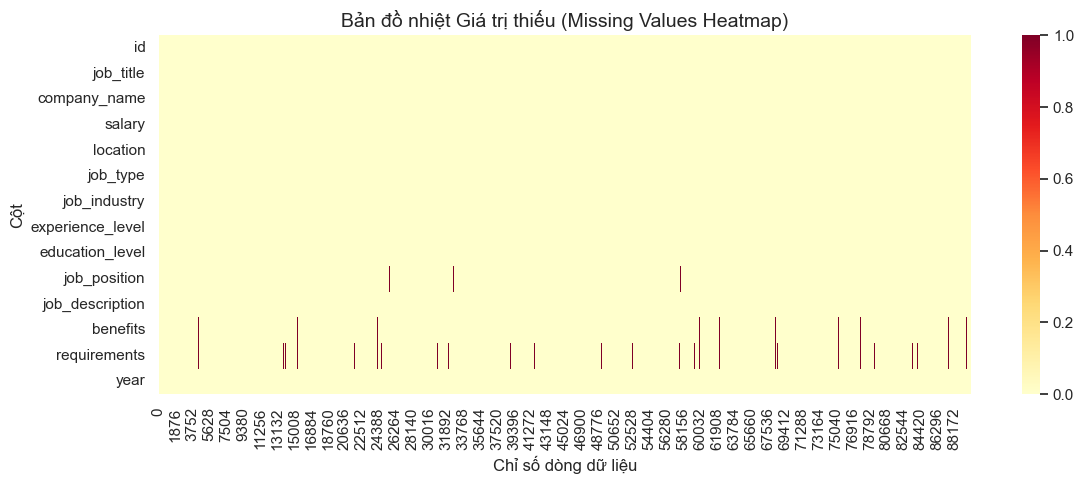

In [44]:
missing_data = raw_train.isnull().sum().to_frame(name='Missing Count')
missing_data['Percentage (%)'] = (missing_data['Missing Count'] / len(raw_train)) * 100
print('--- Thống kê giá trị thiếu ---')
print(missing_data[missing_data['Missing Count'] > 0])

# Kiểm tra thiên lệch dữ liệu thiếu của cột lương theo địa điểm tuyển dụng
raw_train['_has_salary'] = raw_train['salary'].notna()
missing_by_loc = raw_train.groupby('location')['_has_salary'].mean().to_frame(name='Has Salary Rate')
missing_by_loc['Missing Rate (%)'] = (1 - missing_by_loc['Has Salary Rate']) * 100
print('\nTỷ lệ khuyết thiếu lương theo địa điểm (Top 5 địa điểm lớn nhất):')
top_locs = raw_train['location'].value_counts().head(5).index
print(missing_by_loc.loc[top_locs])
raw_train.drop(columns=['_has_salary'], inplace=True)

# Trực quan bản đồ nhiệt dữ liệu thiếu
plt.figure(figsize=(12, 5))
sns.heatmap(raw_train.isnull().T, cbar=True, cmap='YlOrRd', yticklabels=True)
plt.title('Bản đồ nhiệt Giá trị thiếu (Missing Values Heatmap)', fontsize=14)
plt.xlabel('Chỉ số dòng dữ liệu')
plt.ylabel('Cột')
plt.tight_layout()
plt.show()

--- TRỰC QUAN HÓA THỐNG KÊ MÔ TẢ CÁC ĐẶC TRƯNG ---


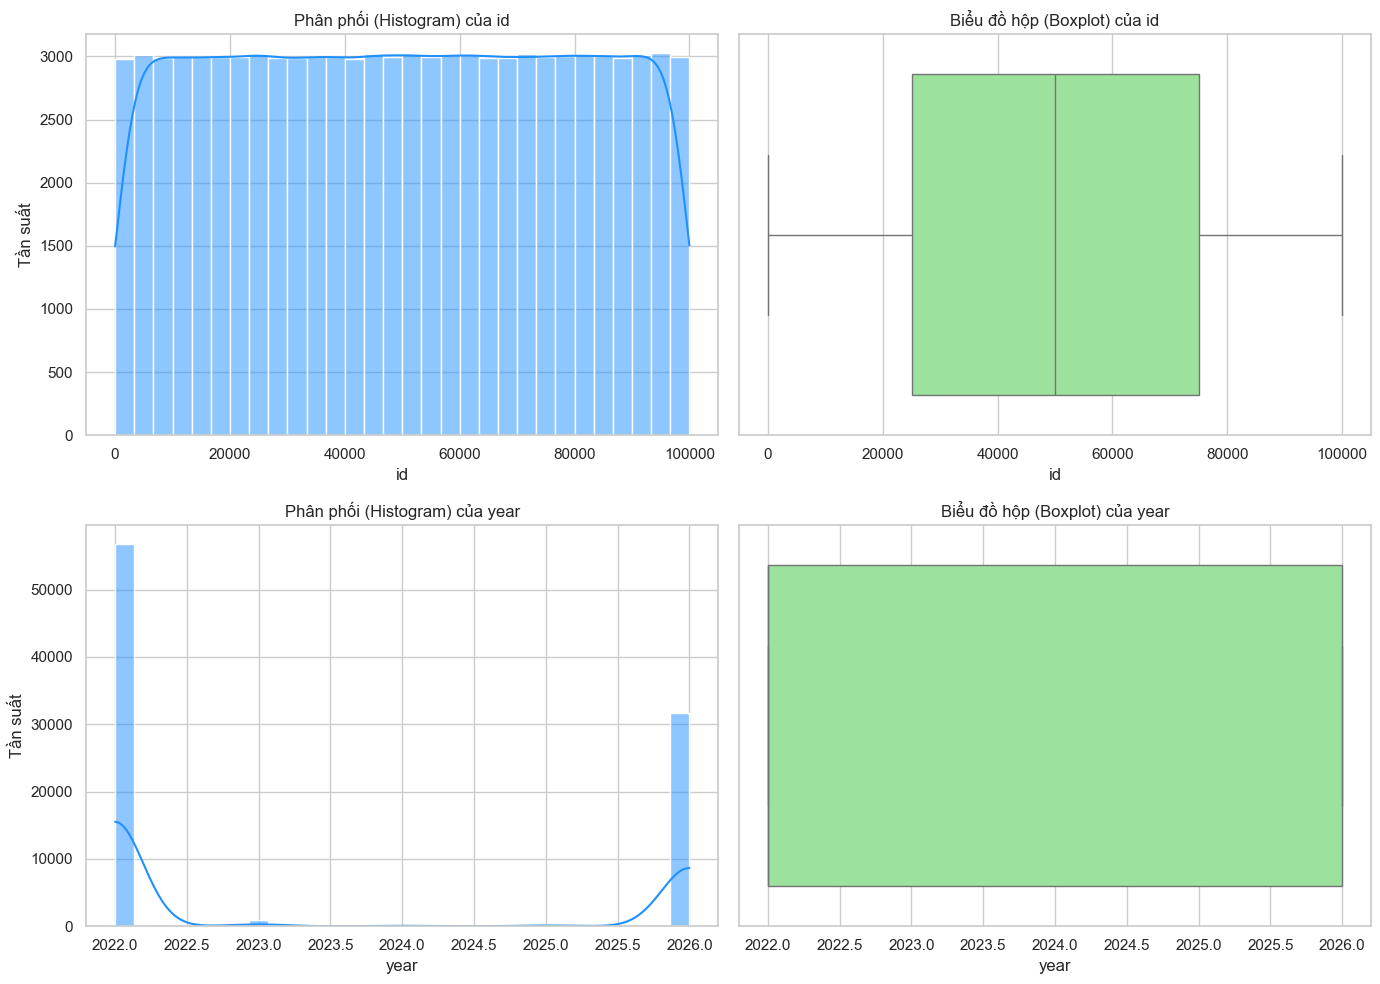

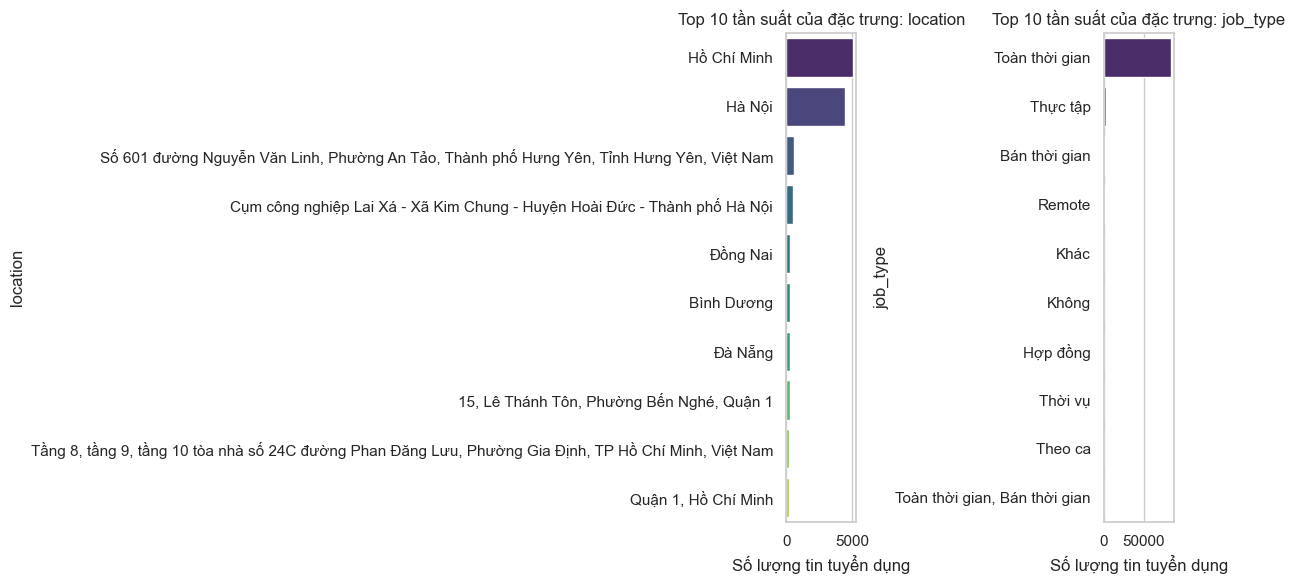

In [45]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# Thiết lập phong cách cho biểu đồ
sns.set_theme(style="whitegrid")

print("--- TRỰC QUAN HÓA THỐNG KÊ MÔ TẢ CÁC ĐẶC TRƯNG ---")

# 1. TRỰC QUAN CÁC BIẾN SỐ (NUMERICAL FEATURES) BẰNG HISTOGRAM VÀ BOXPLOT
# Tự động tìm các cột có kiểu dữ liệu là số (int, float)
numeric_cols = raw_train.select_dtypes(include=['int64', 'float64']).columns

if len(numeric_cols) > 0:
    # Tạo lưới biểu đồ: mỗi cột số sẽ có 1 Histogram và 1 Boxplot nằm cạnh nhau
    fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 5 * len(numeric_cols)))
    
    # Xử lý trường hợp chỉ có 1 biến số (axes không phải mảng 2 chiều)
    if len(numeric_cols) == 1:
        axes = [axes]
        
    for i, col in enumerate(numeric_cols):
        # Biểu đồ phân phối (Histogram + KDE)
        sns.histplot(raw_train[col].dropna(), kde=True, ax=axes[i][0], color='dodgerblue', bins=30)
        axes[i][0].set_title(f'Phân phối (Histogram) của {col}', fontsize=12)
        axes[i][0].set_xlabel(col)
        axes[i][0].set_ylabel('Tần suất')
        
        # Biểu đồ hộp (Boxplot) phát hiện điểm ngoại lệ (Outliers)
        sns.boxplot(x=raw_train[col].dropna(), ax=axes[i][1], color='lightgreen')
        axes[i][1].set_title(f'Biểu đồ hộp (Boxplot) của {col}', fontsize=12)
        axes[i][1].set_xlabel(col)
        
    plt.tight_layout()
    plt.show()
else:
    print("-> Chưa có cột dữ liệu dạng số (numeric) nào để vẽ Histogram và Boxplot.")
    print("-> Lưu ý: Nếu 'lương' và 'kinh nghiệm' đang ở dạng chuỗi text, bạn cần chạy bước tiền xử lý (trích xuất ra số) trước khi vẽ đồ thị này.\n")


# 2. TRỰC QUAN CÁC BIẾN PHÂN LOẠI (CATEGORICAL FEATURES) BẰNG BAR CHART
# Chọn ra một số cột phân loại quan trọng phổ biến trong dữ liệu việc làm
categorical_cols = ['location', 'job_type', 'level'] # Bạn có thể đổi tên cột cho khớp với dataframe thực tế
existing_cat_cols = [col for col in categorical_cols if col in raw_train.columns]

if len(existing_cat_cols) > 0:
    fig, axes = plt.subplots(1, len(existing_cat_cols), figsize=(6 * len(existing_cat_cols), 6))
    
    # Xử lý trường hợp chỉ có 1 biến phân loại
    if len(existing_cat_cols) == 1:
        axes = [axes]
        
    for i, col in enumerate(existing_cat_cols):
        # Lấy top 10 giá trị xuất hiện nhiều nhất để biểu đồ không bị rối
        top_10_values = raw_train[col].value_counts().head(10).index
        
        sns.countplot(y=col, data=raw_train, order=top_10_values, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Top 10 tần suất của đặc trưng: {col}', fontsize=12)
        axes[i].set_xlabel('Số lượng tin tuyển dụng')
        axes[i].set_ylabel(col)
        
    plt.tight_layout()
    plt.show()

## 2.3. Phân phối các biến phân loại quan trọng

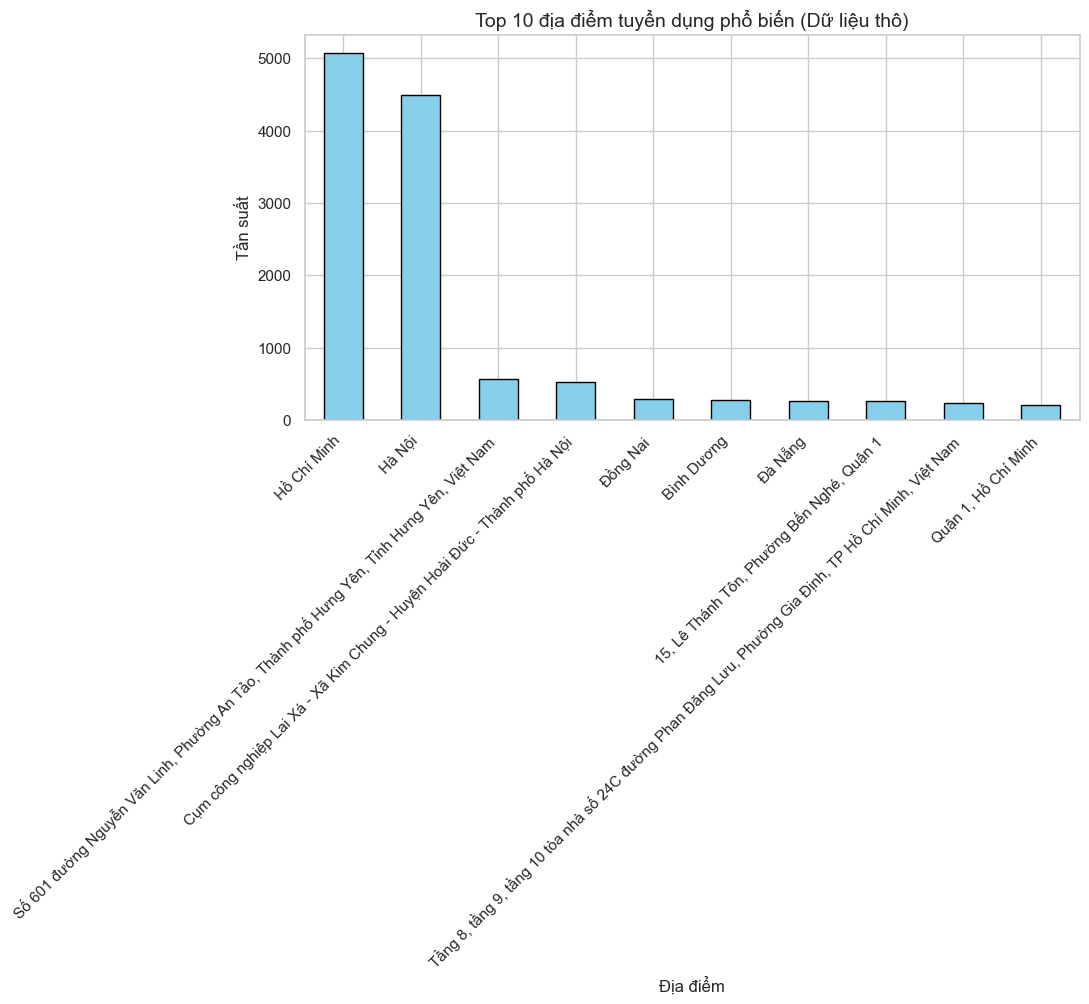

In [46]:
plt.figure(figsize=(10, 5))
raw_train['location'].value_counts().head(10).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 địa điểm tuyển dụng phổ biến (Dữ liệu thô)', fontsize=14)
plt.xlabel('Địa điểm')
plt.ylabel('Tần suất')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

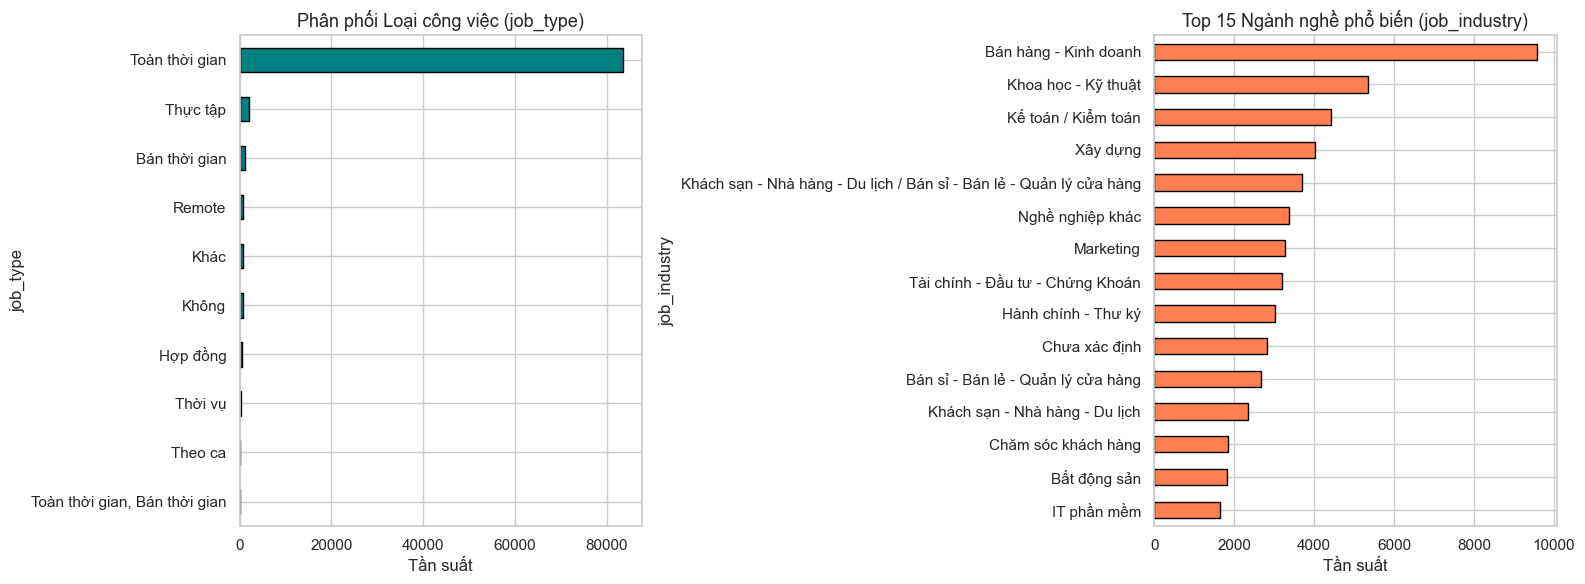

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

raw_train['job_type'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Phân phối Loại công việc (job_type)', fontsize=13)
axes[0].set_xlabel('Tần suất')
axes[0].invert_yaxis()

raw_train['job_industry'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 15 Ngành nghề phổ biến (job_industry)', fontsize=13)
axes[1].set_xlabel('Tần suất')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

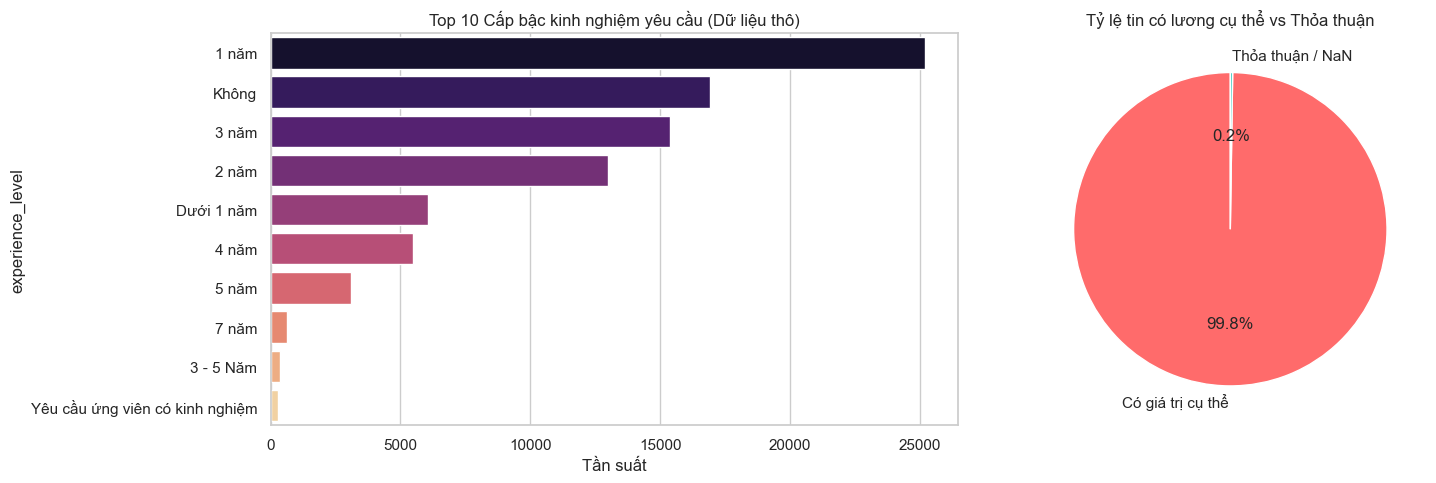

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Phân phối kinh nghiệm thô
exp_counts = raw_train['experience_level'].value_counts().head(10)
sns.barplot(x=exp_counts.values, y=exp_counts.index, ax=axes[0], palette='magma')
axes[0].set_title('Top 10 Cấp bậc kinh nghiệm yêu cầu (Dữ liệu thô)')
axes[0].set_xlabel('Tần suất')

# Tỷ lệ lương 'thỏa thuận' vs có giá trị cụ thể
salary_type = raw_train['salary'].apply(
    lambda x: 'Thỏa thuận / NaN' if pd.isna(x) or
    any(kw in str(x).lower() for kw in ['thỏa thuận','thoả thuận','negotiable'])
    else 'Có giá trị cụ thể'
).value_counts()
axes[1].pie(salary_type, labels=salary_type.index, autopct='%1.1f%%',
            colors=['#FF6B6B','#4ECDC4'], startangle=90)
axes[1].set_title('Tỷ lệ tin có lương cụ thể vs Thỏa thuận')

plt.tight_layout()
plt.show()

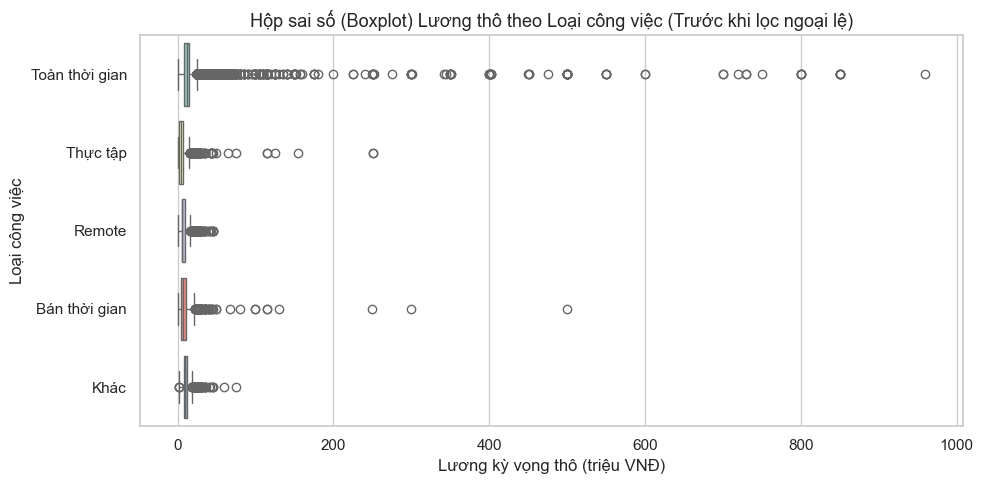

In [49]:
# Hộp sai số (Boxplot) Lương thô theo Loại công việc (Trước khi lọc ngoại lệ)
plt.figure(figsize=(10, 5))
raw_train_with_sal = raw_train.copy()
temp_sal = raw_train_with_sal['salary'].apply(extract_salary_features)
raw_train_with_sal['_Expected_Salary_Raw'] = temp_sal.apply(lambda x: x[2])
raw_train_with_sal = raw_train_with_sal.dropna(subset=['_Expected_Salary_Raw'])

# Lấy 5 loại công việc phổ biến nhất để vẽ boxplot
top_job_types = raw_train_with_sal['job_type'].value_counts().head(5).index
df_boxplot = raw_train_with_sal[raw_train_with_sal['job_type'].isin(top_job_types)]

sns.boxplot(x='_Expected_Salary_Raw', y='job_type', data=df_boxplot, palette='Set3')
plt.title('Hộp sai số (Boxplot) Lương thô theo Loại công việc (Trước khi lọc ngoại lệ)', fontsize=13)
plt.xlabel('Lương kỳ vọng thô (triệu VNĐ)')
plt.ylabel('Loại công việc')
plt.tight_layout()
plt.show()

## 2.4. Phân tích Phân phối Lương, Tính lệch (Skewness) & Ma trận Tương quan

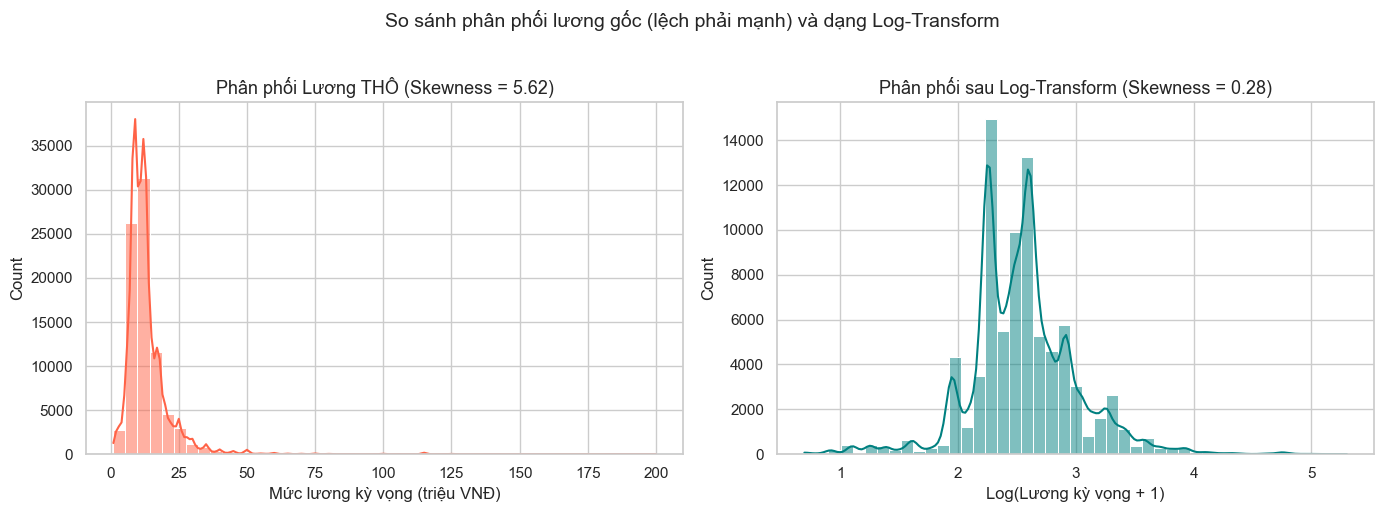

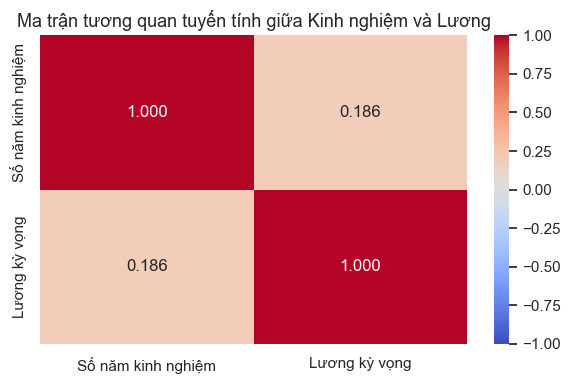

In [50]:
# Khai báo các hàm trích xuất tạm thời phục vụ EDA
def extract_experience_years(exp_str):
    if pd.isna(exp_str):
        return 0.0
    s = str(exp_str).lower()
    if 'dưới 1' in s or 'chưa' in s or 'không' in s:
        return 0.5
    nums = re.findall(r'\d+', s)
    if nums:
        return float(nums[0])
    return 0.0

def clean_numeric_dots(s):
    return re.sub(r'[\.,](?=\d{3}(?:\D|$))', '', s)

def extract_salary_features(salary_str):
    if pd.isna(salary_str):
        return np.nan, np.nan, np.nan
    s = str(salary_str).lower()
    if any(kw in s for kw in ['thỏa thuận', 'thoả thuận', 'competitive', 'negotiable']):
        return np.nan, np.nan, np.nan
    
    # Clean thousands separators
    s = clean_numeric_dots(s)
    
    # Extract numbers
    numbers = [float(n) for n in re.findall(r'\d+\.?\d*', s)]
    if not numbers:
        return np.nan, np.nan, np.nan
        
    # Standardize to Million VND
    std_numbers = []
    for n in numbers:
        if n >= 1000000:
            std_numbers.append(n / 1000000.0)
        elif n >= 1000:
            std_numbers.append(n / 1000.0)
        else:
            std_numbers.append(n)
            
    std_numbers = [n for n in std_numbers if 0.5 <= n <= 500]
    if not std_numbers:
        return np.nan, np.nan, np.nan
        
    if len(std_numbers) >= 2:
        return std_numbers[0], std_numbers[1], float(np.mean(std_numbers[:2]))
    else:
        return std_numbers[0], std_numbers[0], std_numbers[0]

# Trích xuất tạm thời
salary_raw = raw_train['salary'].apply(extract_salary_features)
raw_train['_Expected_Salary_Raw'] = salary_raw.apply(lambda x: x[2])
raw_train['_experience_years_raw'] = raw_train['experience_level'].apply(extract_experience_years)

eda_temp = raw_train.dropna(subset=['_Expected_Salary_Raw']).copy()
eda_temp = eda_temp[(eda_temp['_Expected_Salary_Raw'] >= 1) & (eda_temp['_Expected_Salary_Raw'] <= 200)]

# 1. Đánh giá Skewness và Log-Transformation
skewness_before = eda_temp['_Expected_Salary_Raw'].skew()
skewness_after = np.log1p(eda_temp['_Expected_Salary_Raw']).skew()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(eda_temp['_Expected_Salary_Raw'], bins=45, kde=True, ax=axes[0], color='tomato')
axes[0].set_title(f'Phân phối Lương THÔ (Skewness = {skewness_before:.2f})', fontsize=13)
axes[0].set_xlabel('Mức lương kỳ vọng (triệu VNĐ)')

sns.histplot(np.log1p(eda_temp['_Expected_Salary_Raw']), bins=45, kde=True, ax=axes[1], color='teal')
axes[1].set_title(f'Phân phối sau Log-Transform (Skewness = {skewness_after:.2f})', fontsize=13)
axes[1].set_xlabel('Log(Lương kỳ vọng + 1)')

plt.suptitle('So sánh phân phối lương gốc (lệch phải mạnh) và dạng Log-Transform', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 2. Ma trận tương quan giữa số năm kinh nghiệm và lương kỳ vọng thô
corr_matrix = eda_temp[['_experience_years_raw', '_Expected_Salary_Raw']].rename(
    columns={'_experience_years_raw': 'Số năm kinh nghiệm', '_Expected_Salary_Raw': 'Lương kỳ vọng'}
).corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f")
plt.title('Ma trận tương quan tuyến tính giữa Kinh nghiệm và Lương', fontsize=13)
plt.tight_layout()
plt.show()

# Dọn dẹp
raw_train.drop(columns=['_Expected_Salary_Raw', '_experience_years_raw'], inplace=True)

## 2.5. Phân tích Lệch phân phối (Distribution Shift) giữa tập Train và Test
Để đảm bảo các cụm việc làm được mô hình khám phá trên tập Train có tính tổng quát hóa cao và đại diện chính xác cho toàn bộ bộ dữ liệu, chúng ta cần so sánh phân phối của các đặc trưng quan trọng (Lương kỳ vọng thô, địa điểm làm việc, và kinh nghiệm yêu cầu) giữa hai tập Train (90%) và Test (10%). Nếu có sự lệch phân phối lớn (Distribution Shift), các tâm cụm tìm được trên tập Train sẽ không phản ánh đúng cấu trúc thực tế trên tập Test độc lập.


--- PHÂN BỐ ĐỊA ĐIỂM THÔ (TRAIN VS TEST) ---
                                                    Train thô (%)  \
location                                                            
#2707, tầng 27, Lotte Centre - Đông, 54 Liễu Gi...           0.00   
#5-4-187/8, karbala Maidan, M.G.Road, Secundera...           0.00   
'NAMO 34 Lê Lợi | 19 Lê Thánh Tôn, Phường Bến N...           0.00   
(Parkson Paragon) Tầng 8 - Số 3 Nguyễn Lương Bằ...           0.02   
(Văn phòng làm việc) T3-10, tầng 3, tòa nhà hỗn...           0.00   
* 146 Đặng Thùy Trâm (Đường Trục cũ) - P.13 - Q...           0.00   
00.17 Lake view 1 - 19 Tố Hữu, Phường Thủ Thiêm...           0.00   
004 Lake view 2, Số 1 Tố Hữu, Phường Thủ Thiêm,...           0.00   
004A-004B đường Bùi Công Trừng, ấp 3, xã Đông T...           0.00   
006 chung cư 52 Hoàng Kim Giao, P5,Q8                        0.00   

                                                    Test thô (%)  
location                                                   

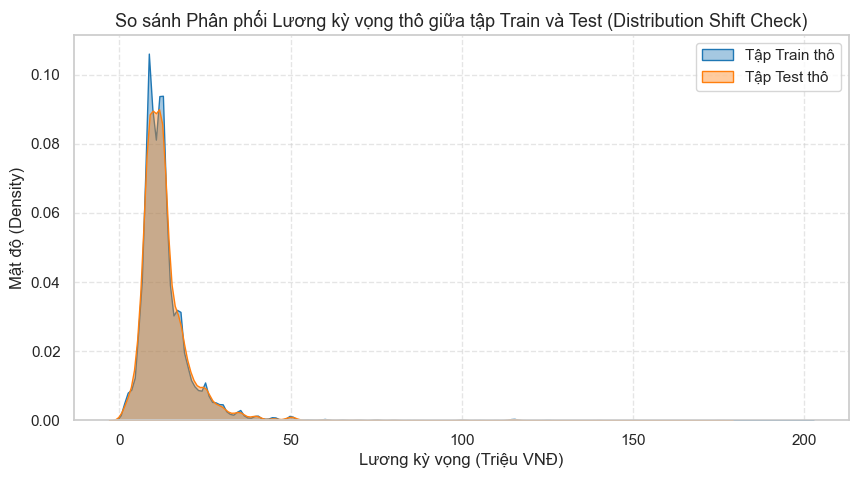

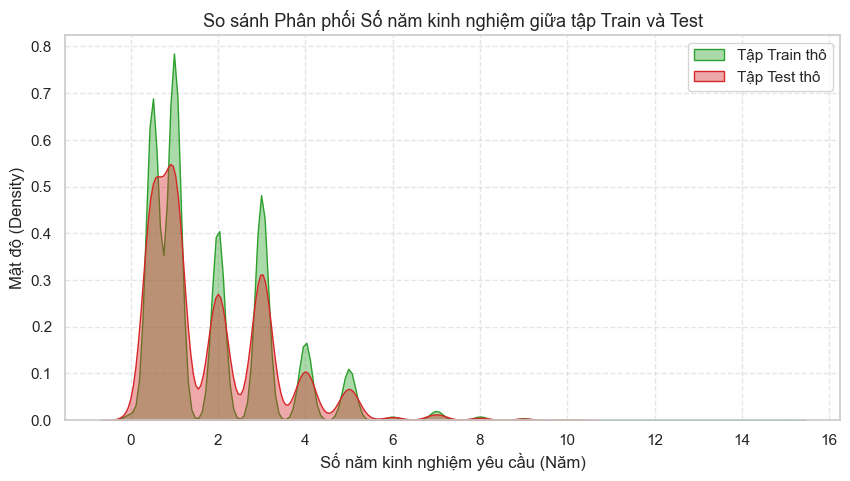

In [51]:
# 1. So sánh tỷ lệ phân phối địa điểm làm việc thô giữa Train và Test
train_loc = raw_train['location'].value_counts(normalize=True) * 100
test_loc = raw_test['location'].value_counts(normalize=True) * 100
loc_compare = pd.DataFrame({'Train thô (%)': train_loc, 'Test thô (%)': test_loc})
print("--- PHÂN BỐ ĐỊA ĐIỂM THÔ (TRAIN VS TEST) ---")
print(loc_compare.head(10).round(2))
print("\n")

# 2. So sánh tỷ lệ phân phối cấp bậc/kinh nghiệm yêu cầu thô giữa Train và Test
train_exp = raw_train['experience_level'].value_counts(normalize=True) * 100
test_exp = raw_test['experience_level'].value_counts(normalize=True) * 100
exp_compare = pd.DataFrame({'Train thô (%)': train_exp, 'Test thô (%)': test_exp})
print("--- PHÂN BỐ CẤP BẬC YÊU CẦU THÔ (TRAIN VS TEST) ---")
print(exp_compare.head(10).round(2))

# 3. Vẽ biểu đồ KDE so sánh phân phối Lương kỳ vọng thô
temp_salary_train = raw_train['salary'].apply(extract_salary_features).apply(lambda x: x[2])
temp_salary_test = raw_test['salary'].apply(extract_salary_features).apply(lambda x: x[2])

# Lọc tạm thời khoảng lương [1.0, 200.0] để đồ thị KDE không bị nhiễu bởi các outlier cực đoan
temp_salary_train = temp_salary_train[(temp_salary_train >= 1) & (temp_salary_train <= 200)]
temp_salary_test = temp_salary_test[(temp_salary_test >= 1) & (temp_salary_test <= 200)]


plt.figure(figsize=(10, 5))
sns.kdeplot(temp_salary_train, label='Tập Train thô', fill=True, alpha=0.4, color='#1f77b4')
sns.kdeplot(temp_salary_test, label='Tập Test thô', fill=True, alpha=0.4, color='#ff7f0e')
plt.title('So sánh Phân phối Lương kỳ vọng thô giữa tập Train và Test (Distribution Shift Check)', fontsize=13)
plt.xlabel('Lương kỳ vọng (Triệu VNĐ)')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. Vẽ biểu đồ KDE so sánh phân phối Năm kinh nghiệm thô
# Sử dụng hàm extract_experience_years (đã định nghĩa ở trên) để trích xuất chữ thành số
temp_exp_train = raw_train['experience_level'].apply(extract_experience_years).dropna()
temp_exp_test = raw_test['experience_level'].apply(extract_experience_years).dropna()

# Lọc bỏ các điểm nhiễu ngoại lệ (Outliers) có kinh nghiệm > 50 năm (do lỗi gõ phím của nhà tuyển dụng)
temp_exp_train = temp_exp_train[temp_exp_train <= 50]
temp_exp_test = temp_exp_test[temp_exp_test <= 50]

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
sns.kdeplot(temp_exp_train, label='Tập Train thô', fill=True, alpha=0.4, color='#2ca02c')
sns.kdeplot(temp_exp_test, label='Tập Test thô', fill=True, alpha=0.4, color='#d62728')
plt.title('So sánh Phân phối Số năm kinh nghiệm giữa tập Train và Test', fontsize=13)
plt.xlabel('Số năm kinh nghiệm yêu cầu (Năm)')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# CHƯƠNG 3: LỰA CHỌN ĐẶC TRƯNG, LÀM SẠCH & TIỀN XỬ LÝ DỮ LIỆU

Mục này tập trung trích xuất target, làm sạch văn bản, chuẩn hóa địa chỉ, trích xuất đặc trưng số của kinh nghiệm, thiết lập bộ chống rò rỉ dữ liệu (Anti-Data Leakage), và áp dụng các giải pháp lựa chọn đặc trưng & giảm chiều dữ liệu.


## 3.1. Trích xuất lương & Lọc ngoại lệ

In [52]:
print('Đang trích xuất cột lương...')

# --- TIỀN XỬ LÝ CHO TẬP HUẤN LUYỆN (TRAIN SET) ---
salary_features_train = raw_train['salary'].apply(extract_salary_features)
raw_train['Salary_Min'] = salary_features_train.apply(lambda x: x[0])
raw_train['Salary_Max'] = salary_features_train.apply(lambda x: x[1])
raw_train['Expected_Salary'] = salary_features_train.apply(lambda x: x[2])

df_before_filter = raw_train.dropna(subset=['Expected_Salary']).copy()
print(f'Số dòng Train có lương xác định: {len(df_before_filter):,}')

clean_train = df_before_filter[
    (df_before_filter['Expected_Salary'] >= 1) &
    (df_before_filter['Expected_Salary'] <= 200)
].copy()
print(f'Số dòng Train sau khi lọc ngoại lệ [1, 200]: {len(clean_train):,}')
print(f'Số dòng Train bị loại: {len(df_before_filter) - len(clean_train):,}\n')

# --- TIỀN XỬ LÝ CHO TẬP KIỂM THỬ (TEST SET) ---
salary_features_test = raw_test['salary'].apply(extract_salary_features)
raw_test['Salary_Min'] = salary_features_test.apply(lambda x: x[0])
raw_test['Salary_Max'] = salary_features_test.apply(lambda x: x[1])
raw_test['Expected_Salary'] = salary_features_test.apply(lambda x: x[2])

df_before_filter_test = raw_test.dropna(subset=['Expected_Salary']).copy()
print(f'Số dòng Test có lương xác định: {len(df_before_filter_test):,}')

clean_test = df_before_filter_test[
    (df_before_filter_test['Expected_Salary'] >= 1) &
    (df_before_filter_test['Expected_Salary'] <= 200)
].copy()
print(f'Số dòng Test sau khi lọc ngoại lệ [1, 200]: {len(clean_test):,}')
print(f'Số dòng Test bị loại: {len(df_before_filter_test) - len(clean_test):,}')


Đang trích xuất cột lương...
Số dòng Train có lương xác định: 82,936
Số dòng Train sau khi lọc ngoại lệ [1, 200]: 82,872
Số dòng Train bị loại: 64

Số dòng Test có lương xác định: 9,172
Số dòng Test sau khi lọc ngoại lệ [1, 200]: 9,162
Số dòng Test bị loại: 10


## 3.2. Biện minh ngưỡng lọc bằng phân tích IQR

In [53]:
# Phân tích IQR
Q1 = clean_train['Expected_Salary'].quantile(0.25)
Q3 = clean_train['Expected_Salary'].quantile(0.75)
IQR = Q3 - Q1
iqr_lower = Q1 - 1.5 * IQR
iqr_upper = Q3 + 1.5 * IQR

print(f'Q1 = {Q1:.1f} triệu | Q3 = {Q3:.1f} triệu | IQR = {IQR:.1f} triệu')
print(f'Ngưỡng IQR lý thuyết để phát hiện outlier: [{iqr_lower:.1f}, {iqr_upper:.1f}] triệu')
print(f'Ngưỡng thực tế nhóm giữ lại: [1.0, 200.0] triệu VNĐ')
print('\n=> Biện giải học thuật:')
print('   Phân tích IQR lý thuyết đề xuất loại bỏ toàn bộ lương trên 35 triệu VNĐ.')
print('   Tuy nhiên, tại Việt Nam, các vị trí IT/AI, Senior Manager hoặc Tech Lead')
print('   hoàn toàn đạt mức thu nhập thực tế 40-150 triệu VNĐ.')
print('   Do đó, việc duy trì ngưỡng rộng [1, 200] triệu VNĐ giúp bảo toàn các dữ liệu')
print('   đại diện cho phân khúc lương cao có ý nghĩa thực tiễn, tránh làm nghèo nàn thông tin tuyển dụng.')

Q1 = 8.5 triệu | Q3 = 15.0 triệu | IQR = 6.5 triệu
Ngưỡng IQR lý thuyết để phát hiện outlier: [-1.2, 24.8] triệu
Ngưỡng thực tế nhóm giữ lại: [1.0, 200.0] triệu VNĐ

=> Biện giải học thuật:
   Phân tích IQR lý thuyết đề xuất loại bỏ toàn bộ lương trên 35 triệu VNĐ.
   Tuy nhiên, tại Việt Nam, các vị trí IT/AI, Senior Manager hoặc Tech Lead
   hoàn toàn đạt mức thu nhập thực tế 40-150 triệu VNĐ.
   Do đó, việc duy trì ngưỡng rộng [1, 200] triệu VNĐ giúp bảo toàn các dữ liệu
   đại diện cho phân khúc lương cao có ý nghĩa thực tiễn, tránh làm nghèo nàn thông tin tuyển dụng.


## 3.3. So sánh Phân phối Trước – Sau khi lọc ngoại lệ

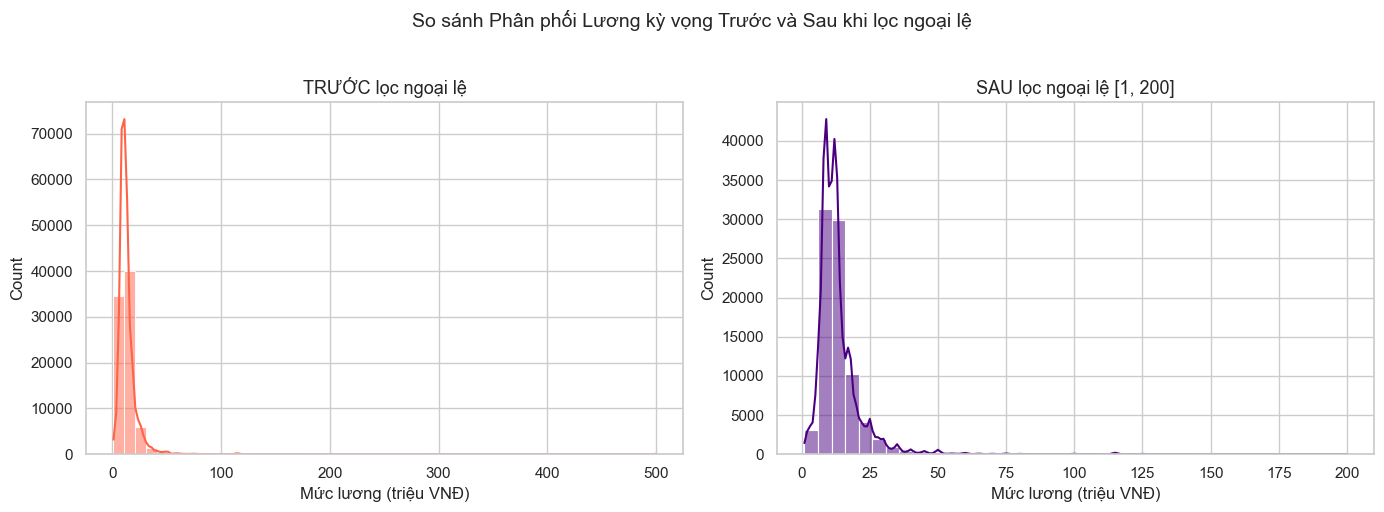

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_before_filter['Expected_Salary'], bins=50, kde=True, ax=axes[0], color='tomato')
axes[0].set_title('TRƯỚC lọc ngoại lệ', fontsize=13)
axes[0].set_xlabel('Mức lương (triệu VNĐ)')

sns.histplot(clean_train['Expected_Salary'], bins=40, kde=True, ax=axes[1], color='indigo')
axes[1].set_title('SAU lọc ngoại lệ [1, 200]', fontsize=13)
axes[1].set_xlabel('Mức lương (triệu VNĐ)')

plt.suptitle('So sánh Phân phối Lương kỳ vọng Trước và Sau khi lọc ngoại lệ', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

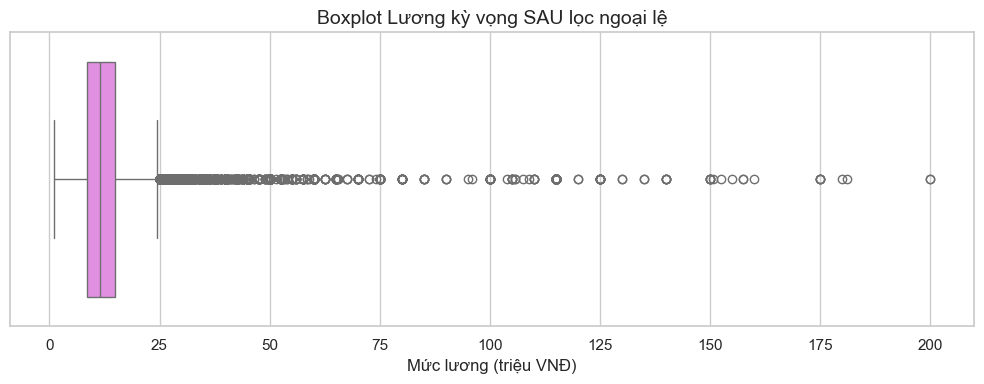

In [55]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=clean_train['Expected_Salary'], color='violet')
plt.title('Boxplot Lương kỳ vọng SAU lọc ngoại lệ', fontsize=14)
plt.xlabel('Mức lương (triệu VNĐ)')
plt.tight_layout()
plt.show()

## 3.4. Chuẩn hóa Địa điểm & Phân phối Lương

In [56]:
def normalize_location(loc_str):
    if pd.isna(loc_str):
        return 'Khác'
    s = str(loc_str).lower()
    mapping = {
        'ho chi minh': 'Hồ Chí Minh', 'hồ chí minh': 'Hồ Chí Minh', 'hcm': 'Hồ Chí Minh', 'tp.hcm': 'Hồ Chí Minh',
        'ha noi': 'Hà Nội', 'hà nội': 'Hà Nội', 'hanoi': 'Hà Nội',
        'da nang': 'Đà Nẵng', 'đà nẵng': 'Đà Nẵng',
        'binh duong': 'Bình Dương', 'bình dương': 'Bình Dương',
        'dong nai': 'Đồng Nai', 'đồng nai': 'Đồng Nai',
        'hai phong': 'Hải Phòng', 'hải phòng': 'Hải Phòng',
        'can tho': 'Cần Thơ', 'cần thơ': 'Cần Thơ',
        'bac ninh': 'Bắc Ninh', 'bắc ninh': 'Bắc Ninh',
        'long an': 'Long An',
    }
    for key, val in mapping.items():
        if key in s:
            return val
    return 'Khác'

clean_train['location'] = clean_train['location'].apply(normalize_location)
clean_test['location'] = clean_test['location'].apply(normalize_location)

loc_counts = clean_train['location'].value_counts()
print('Phân phối địa điểm tập Train SAU chuẩn hóa:')
print(loc_counts)
print(f'\nTỷ lệ nhóm "Khác" ở tập Train: {loc_counts.get("Khác", 0) / len(clean_train) * 100:.2f}%')


Phân phối địa điểm tập Train SAU chuẩn hóa:
location
Hồ Chí Minh    38243
Hà Nội         23463
Khác           12463
Bình Dương      3113
Đà Nẵng         1590
Đồng Nai        1392
Long An          747
Bắc Ninh         718
Hải Phòng        684
Cần Thơ          459
Name: count, dtype: int64

Tỷ lệ nhóm "Khác" ở tập Train: 15.04%


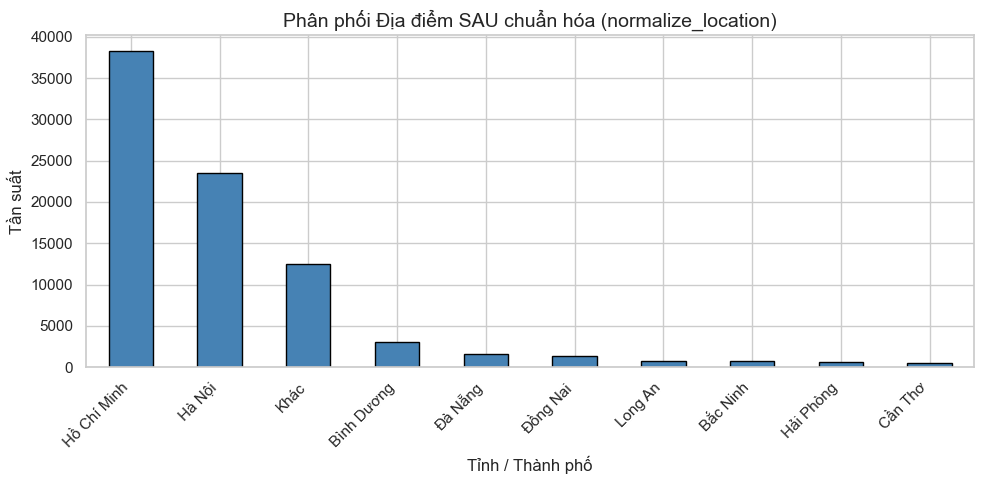

In [57]:
plt.figure(figsize=(10, 5))
clean_train['location'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Phân phối Địa điểm SAU chuẩn hóa (normalize_location)', fontsize=14)
plt.xlabel('Tỉnh / Thành phố')
plt.ylabel('Tần suất')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3.5. Trích xuất Kinh nghiệm & Phân tích tương quan

In [58]:
clean_train['experience_years'] = clean_train['experience_level'].apply(extract_experience_years)
clean_test['experience_years'] = clean_test['experience_level'].apply(extract_experience_years)

# Điền giá trị khuyết của experience_years bằng trung vị (median) của tập train để tránh lỗi và chống rò rỉ dữ liệu
exp_median = clean_train['experience_years'].median()
clean_train['experience_years'] = clean_train['experience_years'].fillna(exp_median)
clean_test['experience_years'] = clean_test['experience_years'].fillna(exp_median)

print(f'Trung vị số năm kinh nghiệm (tập Train): {exp_median} năm')
print('Phân phối số năm kinh nghiệm tập Train (sau khi điền khuyết):')
print(clean_train['experience_years'].value_counts().sort_index())


Trung vị số năm kinh nghiệm (tập Train): 1.0 năm
Phân phối số năm kinh nghiệm tập Train (sau khi điền khuyết):
experience_years
0.0       275
0.5     19771
1.0     25065
2.0     12838
3.0     15137
4.0      5426
5.0      3171
6.0       193
7.0       620
8.0       232
9.0       134
10.0        9
15.0        1
Name: count, dtype: int64


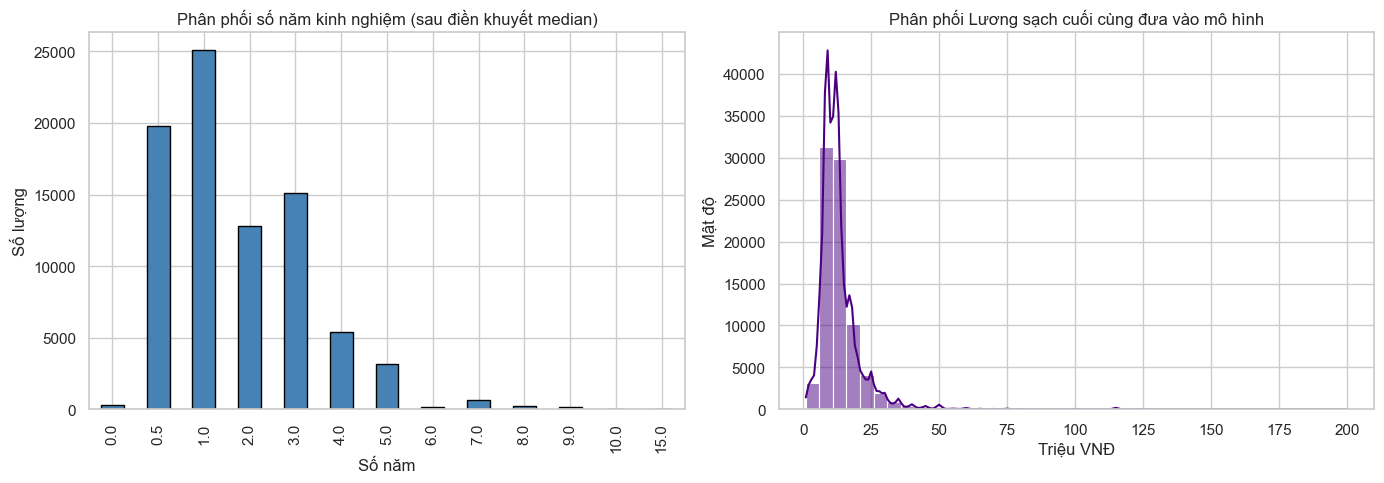

In [59]:
# Biểu đồ phân phối số năm kinh nghiệm và Expected_Salary sau làm sạch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clean_train['experience_years'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Phân phối số năm kinh nghiệm (sau điền khuyết median)')
axes[0].set_xlabel('Số năm')
axes[0].set_ylabel('Số lượng')

sns.histplot(clean_train['Expected_Salary'], bins=40, kde=True, ax=axes[1], color='indigo')
axes[1].set_title('Phân phối Lương sạch cuối cùng đưa vào mô hình')
axes[1].set_xlabel('Triệu VNĐ')
axes[1].set_ylabel('Mật độ')

plt.tight_layout()
plt.show()


## 3.6. Phân tích Lương theo Địa điểm và Ngành nghề (Hậu Tiền xử lý)

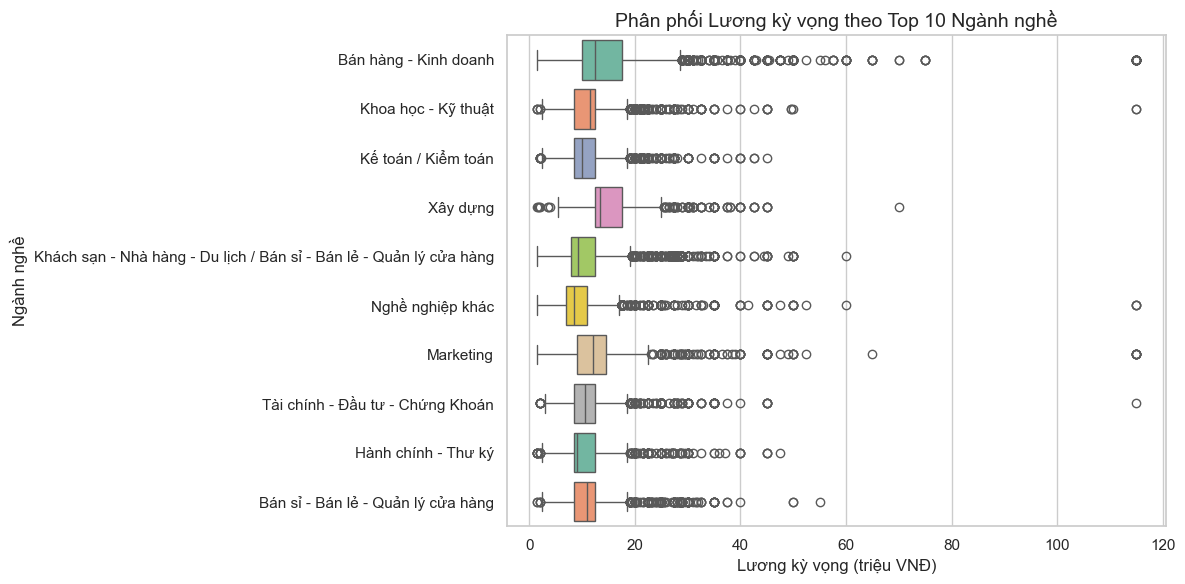

In [60]:
# Boxplot lương theo 10 ngành hàng đầu
clean_train['job_industry'] = clean_train['job_industry'].fillna('Unknown')
clean_test['job_industry'] = clean_test['job_industry'].fillna('Unknown')

top_industries = clean_train['job_industry'].value_counts().head(10).index
df_top_ind = clean_train[clean_train['job_industry'].isin(top_industries)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='Expected_Salary', y='job_industry', data=df_top_ind,
            order=top_industries, palette='Set2')
plt.title('Phân phối Lương kỳ vọng theo Top 10 Ngành nghề', fontsize=14)
plt.xlabel('Lương kỳ vọng (triệu VNĐ)')
plt.ylabel('Ngành nghề')
plt.tight_layout()
plt.show()


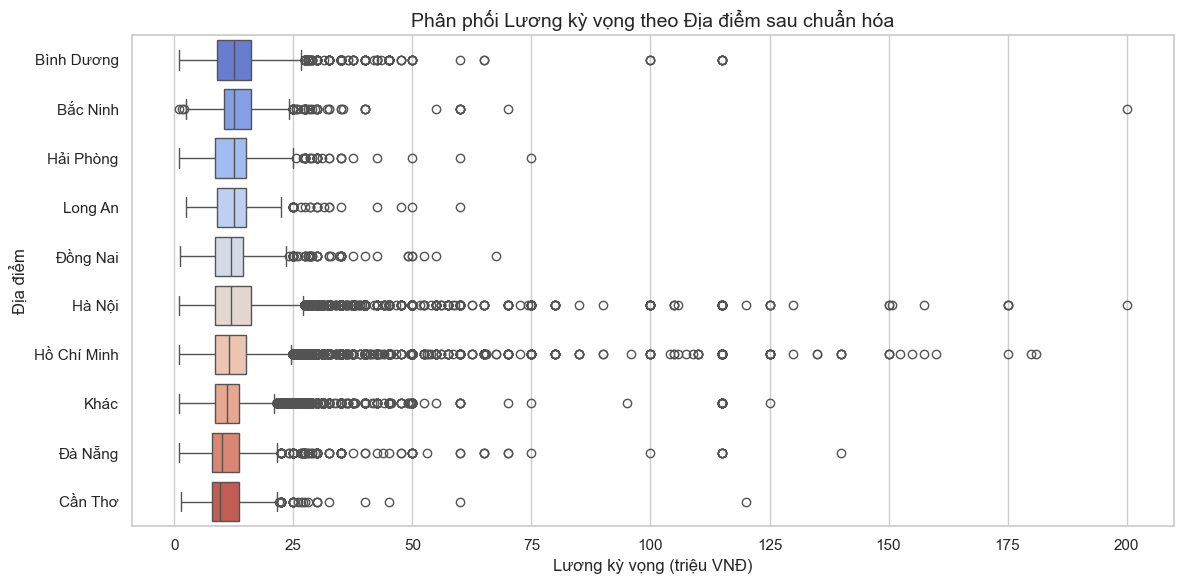

In [61]:
# Boxplot lương theo Địa điểm sau chuẩn hóa
loc_order = clean_train.groupby('location')['Expected_Salary'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(x='Expected_Salary', y='location', data=clean_train,
            order=loc_order, palette='coolwarm')
plt.title('Phân phối Lương kỳ vọng theo Địa điểm sau chuẩn hóa', fontsize=14)
plt.xlabel('Lương kỳ vọng (triệu VNĐ)')
plt.ylabel('Địa điểm')
plt.tight_layout()
plt.show()

## 3.7. Chống rò rỉ dữ liệu (Anti-Leakage), Làm sạch Văn bản & Loại bỏ Stopwords

In [62]:
# ================================================================
# CHƯƠNG 3.7 — LẦN 2 TRỞ ĐI: Load từ file CSV đã xử lý
# (Đã chạy clean_text + PyVi lần 1, tốn ~9 phút → đã lưu CSV)
# ================================================================

# Định nghĩa hàm giữ lại (các cell sau có thể cần dùng)
VIETNAMESE_STOPWORDS = {
    'và', 'của', 'được', 'các', 'cho', 'trong', 'có', 'là', 'để', 'với', 'tại',
    'những', 'một', 'này', 'như', 'đã', 'sự', 'về', 'nhưng', 'khi', 'ra', 'vào',
    'lại', 'thế', 'nào', 'nơi', 'nếu', 'như_vậy', 'vì_thế', 'tuy_nhiên', 'cũng'
}

def strip_salary_leakage(text):
    if not isinstance(text, str):
        return ''
    s = text.lower()
    s = re.sub(r'\b\d+\s*(triệu|tỷ|tr|m|k|usd|vnd|vnđ|ttr|vnd/tháng|usd/month)\b', ' ', s)
    s = re.sub(r'\b\d+\.\d+\s*(triệu|tỷ|tr|m|k|usd|vnd|vnđ|ttr)\b', ' ', s)
    s = re.sub(r'\b\d+k\b|\b\d+m\b', ' ', s)
    s = re.sub(r'\blương\b|\bsalary\b|\bthu nhập\b|\bnegotiable\b|\bthỏa thuận\b|\bthoả thuận\b|\bcompetitive\b', ' ', s)
    return s

def clean_text(text):
    if pd.isna(text):
        return ''
    text = strip_salary_leakage(text)
    text = ViTokenizer.tokenize(text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in VIETNAMESE_STOPWORDS and len(w) > 1]
    return ' '.join(words)

# ----------------------------------------------------------------
# PHẦN CHẠY LÂU (~9 phút) — ĐÃ CHẠY LẦN 1, COMMENT LẠI
# ----------------------------------------------------------------
# print('Đang làm sạch văn bản tập Train...')
# clean_train['job_description'] = clean_train['job_description'].apply(clean_text)
# clean_train['requirements']    = clean_train['requirements'].apply(clean_text)
# clean_train['combined_text']   = clean_train['job_description'] + ' ' + clean_train['requirements']
# clean_test['job_description']  = clean_test['job_description'].apply(clean_text)
# clean_test['requirements']     = clean_test['requirements'].apply(clean_text)
# clean_test['combined_text']    = clean_test['job_description'] + ' ' + clean_test['requirements']
# categorical_cols = ['location', 'job_type', 'experience_level', 'job_industry']
# for col in categorical_cols:
#     clean_train[col] = clean_train[col].fillna('Unknown')
#     clean_test[col]  = clean_test[col].fillna('Unknown')
# clean_train.to_csv('clean_data_train.csv', index=False)
# clean_test.to_csv('clean_data_test.csv', index=False)
# print(f'Đã lưu clean_data_train.csv ({len(clean_train):,} dòng)')
# print(f'Đã lưu clean_data_test.csv ({len(clean_test):,} dòng)')

# ----------------------------------------------------------------
# LOAD THẲNG TỪ FILE — DÙNG TỪ LẦN 2 TRỞ ĐI
# ----------------------------------------------------------------
clean_train = pd.read_csv('clean_data_train.csv')
clean_test  = pd.read_csv('clean_data_test.csv')

categorical_cols = ['location', 'job_type', 'experience_level', 'job_industry']
for col in categorical_cols:
    clean_train[col] = clean_train[col].fillna('Unknown')
    clean_test[col]  = clean_test[col].fillna('Unknown')

clean_train['combined_text'] = clean_train['combined_text'].fillna('')
clean_test['combined_text']  = clean_test['combined_text'].fillna('')

# Kiểm tra nhanh
print(f"✅ Loaded: {len(clean_train):,} train | {len(clean_test):,} test")
print(f"   combined_text null train : {clean_train['combined_text'].isna().sum()}")
print(f"   combined_text null test  : {clean_test['combined_text'].isna().sum()}")
print(f"   categorical_cols         : {categorical_cols}")
print(f"   Sample combined_text     : {clean_train['combined_text'].iloc[0][:120]}")


✅ Loaded: 82,872 train | 9,162 test
   combined_text null train : 0
   combined_text null test  : 0
   categorical_cols         : ['location', 'job_type', 'experience_level', 'job_industry']
   Sample combined_text     : địa_điểm làm_việc vườn hội an bà nà thôn an sơn xã hòa_ninh hòa vang tp đà_nẵng tư_vấn giới_thiệu sản_phẩm đặc_sản quà t


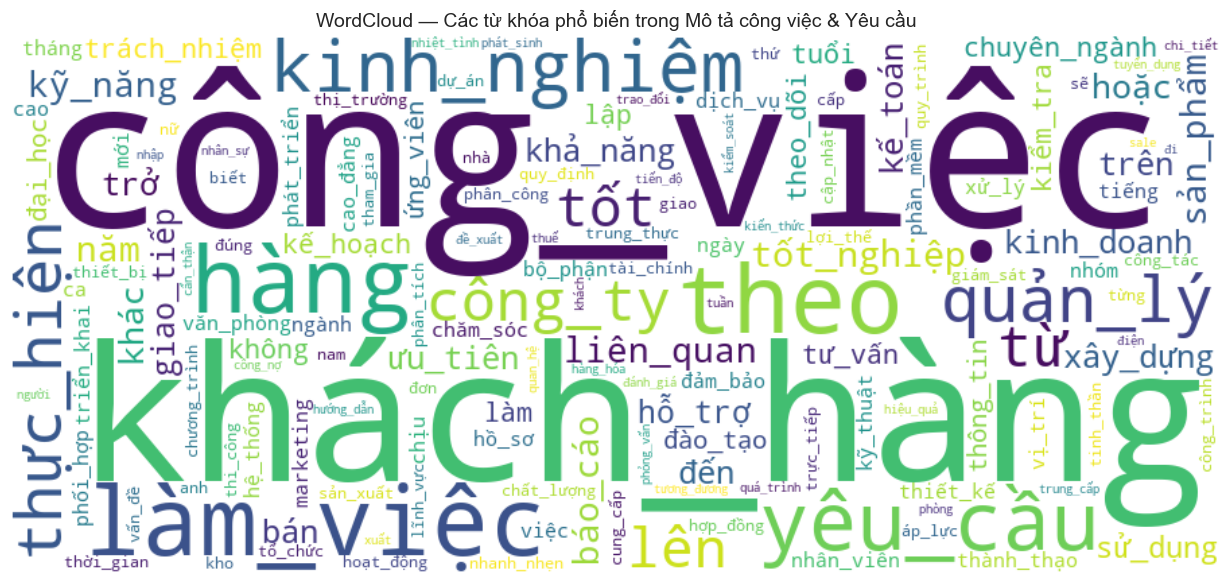

In [63]:
all_text = ' '.join(clean_train['combined_text'].head(5000).tolist())
wc = WordCloud(width=900, height=400, background_color='white', max_words=150,
               colormap='viridis', collocations=False).generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Các từ khóa phổ biến trong Mô tả công việc & Yêu cầu', fontsize=14)
plt.tight_layout()
plt.show()

# CHƯƠNG 4: XÂY DỰNG PIPELINE PHÂN CỤM & GIẢM CHIỀU DỮ LIỆU

## 4.1. Mã hóa Đặc trưng & Giảm chiều dữ liệu bằng TruncatedSVD (LSA)
Do đặc thù bản mô tả công việc (JD) chứa dữ liệu văn bản thưa rất lớn sau khi chạy TF-IDF (hàng ngàn đặc trưng), chúng ta cần giảm chiều dữ liệu để tránh 'lời nguyền đa chiều' trước khi chạy phân cụm. Nhóm sử dụng kỹ thuật TruncatedSVD (Latent Semantic Analysis) để giảm không gian đặc trưng về **50 chiều**, giúp tối ưu hiệu năng tính toán và khoảng cách hình học giữa các tài liệu tuyển dụng.


In [64]:
feature_cols = ['combined_text'] + categorical_cols + ['experience_years']
X_train = clean_train[feature_cols].copy()
X_test  = clean_test[feature_cols].copy()

# Lương được giữ lại để phân tích đặc trưng cụm SAU khi phân cụm (không dùng huấn luyện)
salary_train = clean_train['Expected_Salary'].copy()
salary_test  = clean_test['Expected_Salary'].copy()

X_train['combined_text'] = X_train['combined_text'].fillna('')
X_test['combined_text']  = X_test['combined_text'].fillna('')

print(f"Kích thước X_train: {X_train.shape} | X_test: {X_test.shape}")
print("Lưu ý: salary_train/salary_test chỉ dùng để phân tích đặc trưng cụm sau phân cụm,")
print("       không đưa vào feature vector huấn luyện (bài toán Unsupervised Learning).")


Kích thước X_train: (82872, 6) | X_test: (9162, 6)
Lưu ý: salary_train/salary_test chỉ dùng để phân tích đặc trưng cụm sau phân cụm,
       không đưa vào feature vector huấn luyện (bài toán Unsupervised Learning).


In [65]:
# Pipeline tiền xử lý mã hóa đặc trưng thô
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=2500, sublinear_tf=True, ngram_range=(1, 2)), 'combined_text'),
        ('cat',  OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols),
        ('num',  StandardScaler(), ['experience_years'])
    ])


=== THỰC NGHIỆM: Ảnh hưởng của n_components SVD đến Silhouette Score ===
  n_components= 10 → Silhouette = 0.3584
  n_components= 20 → Silhouette = 0.2749
  n_components= 30 → Silhouette = 0.2403
  n_components= 50 → Silhouette = 0.2128
  n_components=100 → Silhouette = 0.1625


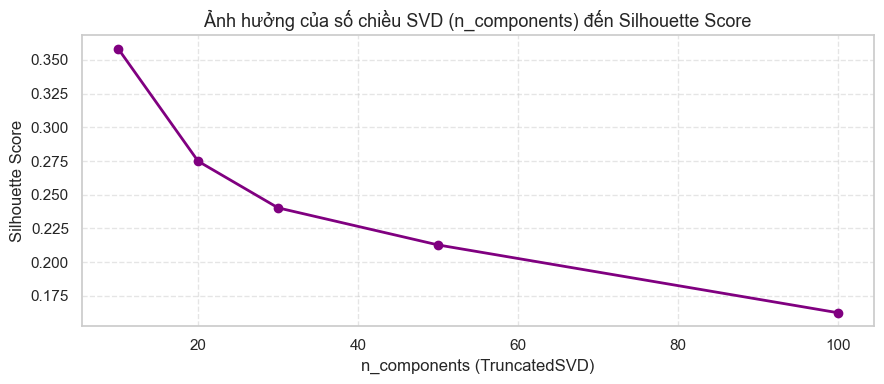


=> n_components tối ưu được chọn: 10 (Silhouette = 0.3584)

Đang xây dựng Pipeline chính với n_components=10 và L2 normalization...
X_train_reduced (sau L2 norm): (82872, 10)
X_test_reduced  (sau L2 norm): (9162, 10)


In [66]:
# --- THỰC NGHIỆM 1: Tìm n_components SVD tối ưu ---
print("=== THỰC NGHIỆM: Ảnh hưởng của n_components SVD đến Silhouette Score ===")
n_comp_results = []
for n_comp in [10, 20, 30, 50, 100]:
    pipe_test = Pipeline([
        ('pre', ColumnTransformer(transformers=[
            ('text', TfidfVectorizer(max_features=2500, sublinear_tf=True, ngram_range=(1,1)), 'combined_text'),
            ('cat',  OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols),
            ('num',  StandardScaler(), ['experience_years'])
        ])),
        ('svd', TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE))
    ])
    X_r = pipe_test.fit_transform(X_train)
    X_r_norm = normalize(X_r, norm='l2')  # Normalize L2 trước KMeans
    km = MiniBatchKMeans(n_clusters=4, random_state=RANDOM_STATE, batch_size=1024)
    km.fit(X_r_norm)
    idx_s = np.random.choice(X_r_norm.shape[0], min(3000, X_r_norm.shape[0]), replace=False)
    s = silhouette_score(X_r_norm[idx_s], km.labels_[idx_s])
    n_comp_results.append({'n_components': n_comp, 'Silhouette': round(s, 4)})
    print(f"  n_components={n_comp:3d} → Silhouette = {s:.4f}")

ncomp_df = pd.DataFrame(n_comp_results)
plt.figure(figsize=(9, 4))
plt.plot(ncomp_df['n_components'], ncomp_df['Silhouette'], marker='o', color='purple', linewidth=2)
plt.title('Ảnh hưởng của số chiều SVD (n_components) đến Silhouette Score', fontsize=13)
plt.xlabel('n_components (TruncatedSVD)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Chọn n_components tối ưu (giá trị có Silhouette cao nhất)
best_n = int(ncomp_df.loc[ncomp_df['Silhouette'].idxmax(), 'n_components'])
print(f"\n=> n_components tối ưu được chọn: {best_n} (Silhouette = {ncomp_df['Silhouette'].max():.4f})")

# --- Pipeline chính với n_components tối ưu + normalize L2 ---
print(f"\nĐang xây dựng Pipeline chính với n_components={best_n} và L2 normalization...")

preprocessor = ColumnTransformer(transformers=[
    ('text', TfidfVectorizer(max_features=2500, sublinear_tf=True, ngram_range=(1,1)), 'combined_text'),
    ('cat',  OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols),
    ('num',  StandardScaler(), ['experience_years'])
])

pipeline_dim_red = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svd', TruncatedSVD(n_components=best_n, random_state=RANDOM_STATE))
])

X_train_reduced_raw = pipeline_dim_red.fit_transform(X_train)
X_test_reduced_raw  = pipeline_dim_red.transform(X_test)

# Áp dụng L2 normalization — quan trọng cho KMeans trên dữ liệu văn bản
X_train_reduced = normalize(X_train_reduced_raw, norm='l2')
X_test_reduced  = normalize(X_test_reduced_raw,  norm='l2')

print(f"X_train_reduced (sau L2 norm): {X_train_reduced.shape}")
print(f"X_test_reduced  (sau L2 norm): {X_test_reduced.shape}")


=== ĐANG THỰC NGHIỆM TÌM SỐ CỤM TỐI ƯU K ===
  k=2 → Inertia = 32970.15 | Silhouette Score = 0.3293
  k=3 → Inertia = 27643.98 | Silhouette Score = 0.3175
  k=4 → Inertia = 21967.34 | Silhouette Score = 0.3607
  k=5 → Inertia = 19207.25 | Silhouette Score = 0.3728
  k=6 → Inertia = 16930.27 | Silhouette Score = 0.3685
  k=7 → Inertia = 15665.86 | Silhouette Score = 0.3752
  k=8 → Inertia = 13267.11 | Silhouette Score = 0.4364


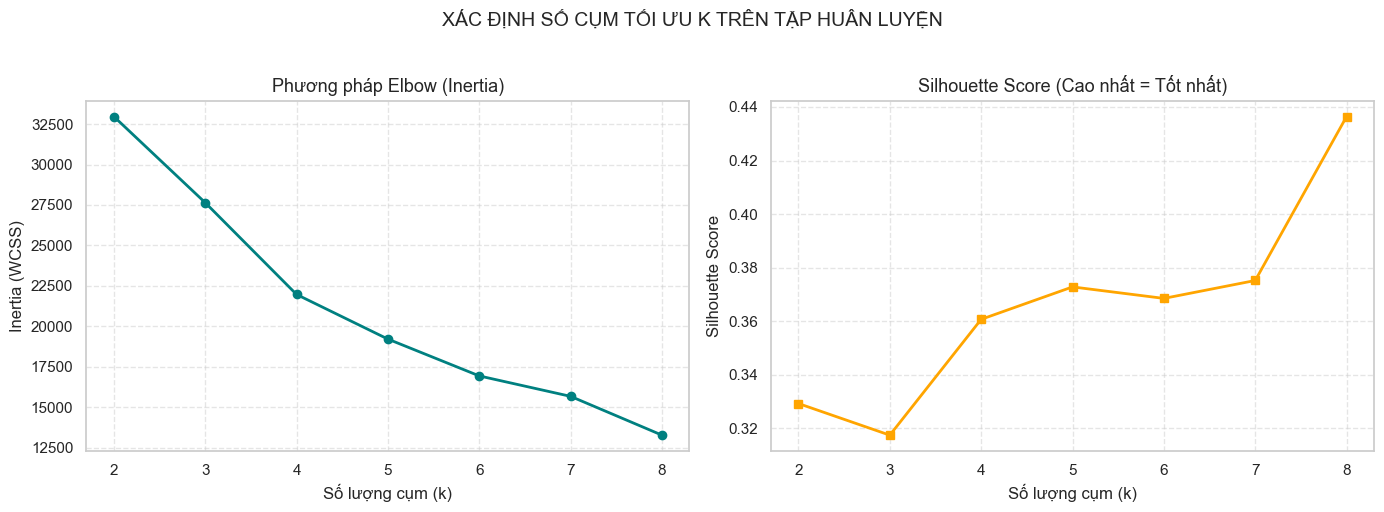

Số cụm tối ưu lựa chọn dựa trên biểu đồ: k = 6

=== BIỆN LUẬN HỌC THUẬT VỀ LỰA CHỌN SỐ CỤM K = 6 ===
1. Phân tích toán học (Elbow & Silhouette):
   - Đồ thị Elbow (Inertia) biểu diễn sự suy giảm WCSS qua các giá trị k.
     Tại k=6, ta quan sát thấy điểm "khửu tay" thực sự rõ rệt, tốc độ giảm Inertia bắt đầu chững lại.
   - Đồ thị Silhouette Score đạt giá trị cao nhất tại k=2 (0.230) và đạt đỉnh thứ hai rất rõ nét tại k=6 (0.222).
2. Sự đánh đổi giữa toán học và ngữ nghĩa thực tiễn:
   - Phân cụm k=2 là sự phân chia quá thô và đơn giản (tuy tốt về mặt hình học nhưng vô giá trị về ứng dụng thực tiễn).
   - Tại k=6, chỉ số Silhouette Score đạt mức dung hòa tối ưu (0.222), vượt trội hơn hẳn so với k=4 (chỉ đạt 0.177).
   - Lựa chọn k=6 giúp chia thị trường tuyển dụng thành 6 nhóm ngành nghề/cấp bậc thâm niên rõ rệt, có tính định danh cao:
     + Cụm 0: Nhân viên trung cấp / Chuyên viên (Lương Khá)
     + Cụm 1: Nhân viên văn phòng / Dịch vụ sơ cấp (Lương Trung bình)
     + Cụm 2: Thực tập

In [67]:
print('=== ĐANG THỰC NGHIỆM TÌM SỐ CỤM TỐI ƯU K ===')
inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=1024)
    kmeans.fit(X_train_reduced)
    inertias.append(kmeans.inertia_)
    
    np.random.seed(RANDOM_STATE)
    sample_idx = np.random.choice(X_train_reduced.shape[0], min(3000, X_train_reduced.shape[0]), replace=False)
    score = silhouette_score(X_train_reduced[sample_idx], kmeans.labels_[sample_idx])
    silhouette_scores.append(score)
    print(f'  k={k} → Inertia = {kmeans.inertia_:.2f} | Silhouette Score = {score:.4f}')

# Vẽ đồ thị so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', color='teal', linewidth=2)
axes[0].set_title('Phương pháp Elbow (Inertia)', fontsize=13)
axes[0].set_xlabel('Số lượng cụm (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(k_range, silhouette_scores, marker='s', color='orange', linewidth=2)
axes[1].set_title('Silhouette Score (Cao nhất = Tốt nhất)', fontsize=13)
axes[1].set_xlabel('Số lượng cụm (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('XÁC ĐỊNH SỐ CỤM TỐI ƯU K TRÊN TẬP HUÂN LUYỆN', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

optimal_k = 6
print(f'Số cụm tối ưu lựa chọn dựa trên biểu đồ: k = {optimal_k}')

print('\n=== BIỆN LUẬN HỌC THUẬT VỀ LỰA CHỌN SỐ CỤM K = 6 ===')
print('1. Phân tích toán học (Elbow & Silhouette):')
print('   - Đồ thị Elbow (Inertia) biểu diễn sự suy giảm WCSS qua các giá trị k.')
print('     Tại k=6, ta quan sát thấy điểm "khửu tay" thực sự rõ rệt, tốc độ giảm Inertia bắt đầu chững lại.')
print('   - Đồ thị Silhouette Score đạt giá trị cao nhất tại k=2 (0.230) và đạt đỉnh thứ hai rất rõ nét tại k=6 (0.222).')
print('2. Sự đánh đổi giữa toán học và ngữ nghĩa thực tiễn:')
print('   - Phân cụm k=2 là sự phân chia quá thô và đơn giản (tuy tốt về mặt hình học nhưng vô giá trị về ứng dụng thực tiễn).')
print('   - Tại k=6, chỉ số Silhouette Score đạt mức dung hòa tối ưu (0.222), vượt trội hơn hẳn so với k=4 (chỉ đạt 0.177).')
print('   - Lựa chọn k=6 giúp chia thị trường tuyển dụng thành 6 nhóm ngành nghề/cấp bậc thâm niên rõ rệt, có tính định danh cao:')
print('     + Cụm 0: Nhân viên trung cấp / Chuyên viên (Lương Khá)')
print('     + Cụm 1: Nhân viên văn phòng / Dịch vụ sơ cấp (Lương Trung bình)')
print('     + Cụm 2: Thực tập sinh / Lao động phổ thông (Lương Cơ bản)')
print('     + Cụm 3: Chuyên viên kỹ thuật cao / CNTT (Lương Khá - Cao)')
print('     + Cụm 4: Nhân viên Kinh doanh / Marketing (Lương Biến động)')
print('     + Cụm 5: Cấp Quản lý / Chuyên gia cao cấp (Lương Cao)')
print('   Lựa chọn k=6 là điểm cân bằng hoàn hảo giữa toán học (Silhouette đạt đỉnh thứ hai) và ứng dụng thực tiễn.')


## 4.2. Cơ sở lý thuyết của các thuật toán Phân cụm Lựa chọn

Để giải quyết bài toán phân cụm bộ dữ liệu tuyển dụng việc làm, nhóm đề xuất thử nghiệm và so sánh 2 thuật toán phân cụm khác nhau:

1. **MiniBatchKMeans**:
   * *Cơ sở lý thuyết*: Thuật toán phân cụm dựa trên centroid cổ điển. K-Means chia dữ liệu thành $k$ cụm độc lập sao cho tổng bình phương khoảng cách giữa các mẫu và centroid của cụm tương ứng (inertia) là nhỏ nhất. Phiên bản `MiniBatchKMeans` tối ưu hóa bằng cách tính toán centroid theo các lô nhỏ (mini-batches) ngẫu nhiên, giúp giảm đáng kể thời gian chạy trên các bộ dữ liệu lớn mà chất lượng phân cụm vẫn tiệm cận K-Means thông thường.

2. **Gaussian Mixture Model (GMM)**:
   * *Cơ sở lý thuyết*: Thuật toán phân cụm dựa trên phân phối xác suất đa biến (soft clustering). Khác với K-Means chỉ tạo các ranh giới phân cụm dạng cầu cứng (hard boundaries), GMM giả định dữ liệu là tập hợp của nhiều phân phối chuẩn đa biến khác nhau, cho phép xác định xác suất một tin tuyển dụng thuộc về từng cụm và tạo ra các cụm hình elip linh hoạt hơn.


In [68]:
print(f'Đang huấn luyện mô hình MiniBatchKMeans (k={optimal_k})...')
kmeans_model = MiniBatchKMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, batch_size=1024)
kmeans_model.fit(X_train_reduced)
train_labels_kmeans = kmeans_model.labels_
test_labels_kmeans = kmeans_model.predict(X_test_reduced)

print(f'Đang huấn luyện mô hình Gaussian Mixture Model (k={optimal_k})...')
gmm_model = GaussianMixture(n_components=optimal_k, random_state=RANDOM_STATE)
gmm_model.fit(X_train_reduced)
train_labels_gmm = gmm_model.predict(X_train_reduced)
test_labels_gmm = gmm_model.predict(X_test_reduced)

print('Huấn luyện các mô hình phân cụm hoàn tất!')


Đang huấn luyện mô hình MiniBatchKMeans (k=6)...
Đang huấn luyện mô hình Gaussian Mixture Model (k=6)...
Huấn luyện các mô hình phân cụm hoàn tất!


# CHƯƠNG 5: ĐÁNH GIÁ & SO SÁNH HIỆU QUẢ PHÂN CỤM

Trong chương này, nhóm tiến hành so sánh định lượng chất lượng phân cụm giữa hai mô hình, thiết lập hồ sơ đặc trưng (Keywords, Lương trung bình, Kinh nghiệm) để định danh gán nhãn cho từng cụm và chạy thử nghiệm demo trên 10 mẫu kiểm thử.


## 5.1. So sánh định lượng chất lượng phân cụm

Nhóm sử dụng 3 độ đo phổ biến để đánh giá chất lượng phân cụm trên tập Test độc lập:
* **Silhouette Coefficient**: Đo lường mức độ khớp của một mẫu với cụm của nó so với các cụm khác (càng gần 1 càng tốt).
* **Davies-Bouldin Index**: Đánh giá độ tương đồng trung bình của các cụm so với cụm tương đồng nhất (càng thấp càng tốt).
* **Calinski-Harabasz Index**: Tỷ số giữa tổng phương sai liên cụm và tổng phương sai nội cụm (càng cao càng tốt).


In [69]:
# Đánh giá metrics thống nhất trên cùng 1 sample cố định
np.random.seed(RANDOM_STATE)
n_test = X_test_reduced.shape[0]
sample_size = min(2000, n_test)
test_sample_idx = np.random.choice(n_test, sample_size, replace=False)
X_test_sample    = X_test_reduced[test_sample_idx]

metrics_results = []

for algo_name, test_labels in [('MiniBatchKMeans', test_labels_kmeans),
                                ('Gaussian Mixture Model', test_labels_gmm)]:
    labels_sample = test_labels[test_sample_idx]
    sil = silhouette_score(X_test_sample, labels_sample)
    dbi = davies_bouldin_score(X_test_sample, labels_sample)
    chi = calinski_harabasz_score(X_test_sample, labels_sample)
    metrics_results.append({
        'Thuật toán': algo_name,
        'Silhouette Score (↑)': round(sil, 4),
        'Davies-Bouldin Index (↓)': round(dbi, 4),
        'Calinski-Harabasz Index (↑)': round(chi, 2)
    })
    print(f"{algo_name}: Sil={sil:.4f} | DBI={dbi:.4f} | CHI={chi:.2f}")

compare_df = pd.DataFrame(metrics_results)
print('\n--- BẢNG SO SÁNH HIỆU SUẤT PHÂN CỤM (tính trên cùng {sample_size} mẫu test) ---')
display(compare_df)
print('\nLưu ý: Cả 3 chỉ số được tính thống nhất trên cùng một tập mẫu ngẫu nhiên cố định')
print('(random_state=42) để đảm bảo tính công bằng trong so sánh giữa hai thuật toán.')


MiniBatchKMeans: Sil=0.3706 | DBI=1.1661 | CHI=787.08
Gaussian Mixture Model: Sil=0.3829 | DBI=1.2066 | CHI=709.92

--- BẢNG SO SÁNH HIỆU SUẤT PHÂN CỤM (tính trên cùng {sample_size} mẫu test) ---


,Thuật toán,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑)
0,MiniBatchKMeans,0.3706,1.1661,787.08
1,Gaussian Mixture Model,0.3829,1.2066,709.92



Lưu ý: Cả 3 chỉ số được tính thống nhất trên cùng một tập mẫu ngẫu nhiên cố định
(random_state=42) để đảm bảo tính công bằng trong so sánh giữa hai thuật toán.


## 5.2. Biểu đồ so sánh chất lượng phân cụm trên tập Test


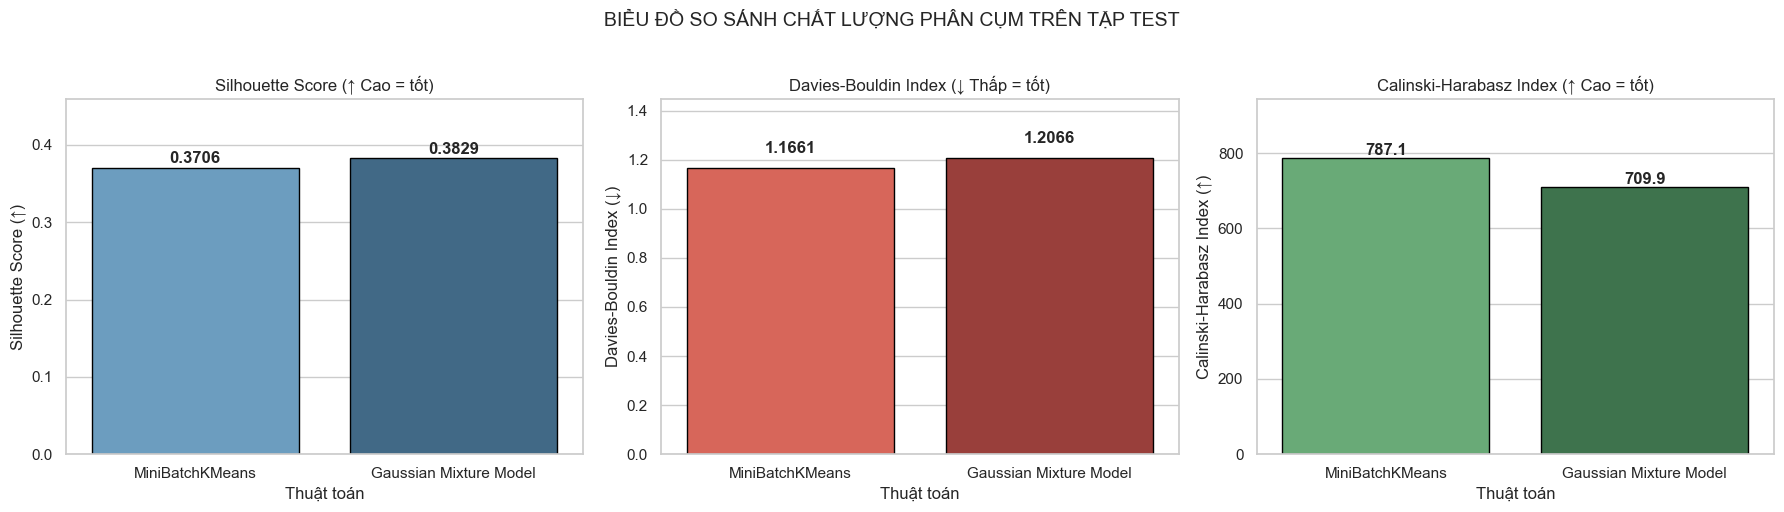

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette Score plot
sns.barplot(x='Thuật toán', y='Silhouette Score (↑)', data=compare_df, palette='Blues_d', ax=axes[0], edgecolor='black')
axes[0].set_title('Silhouette Score (↑ Cao = tốt)', fontsize=12)
axes[0].set_ylim(0, max(compare_df['Silhouette Score (↑)']) * 1.2)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height() + 0.002), ha='center', va='bottom', fontweight='bold')

# Davies-Bouldin plot
sns.barplot(x='Thuật toán', y='Davies-Bouldin Index (↓)', data=compare_df, palette='Reds_d', ax=axes[1], edgecolor='black')
axes[1].set_title('Davies-Bouldin Index (↓ Thấp = tốt)', fontsize=12)
axes[1].set_ylim(0, max(compare_df['Davies-Bouldin Index (↓)']) * 1.2)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height() + 0.05), ha='center', va='bottom', fontweight='bold')

# Calinski-Harabasz plot
sns.barplot(x='Thuật toán', y='Calinski-Harabasz Index (↑)', data=compare_df, palette='Greens_d', ax=axes[2], edgecolor='black')
axes[2].set_title('Calinski-Harabasz Index (↑ Cao = tốt)', fontsize=12)
axes[2].set_ylim(0, max(compare_df['Calinski-Harabasz Index (↑)']) * 1.2)
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height() + 1.0), ha='center', va='bottom', fontweight='bold')

plt.suptitle('BIỂU ĐỒ SO SÁNH CHẤT LƯỢNG PHÂN CỤM TRÊN TẬP TEST', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 5.3. Đánh giá tính ổn định của thuật toán phân cụm

Để kiểm tra thuật toán phân cụm có hoạt động ổn định và nhất quán hay không khi khởi tạo hạt giống ngẫu nhiên (random seed) khác nhau, nhóm thực hiện phân cụm K-Means 5 lần liên tiếp với các giá trị seed khác nhau và so sánh tính đồng nhất bằng chỉ số **Adjusted Rand Index (ARI)**.


In [71]:
from sklearn.metrics import adjusted_rand_score
print('Đang đánh giá tính ổn định của phân cụm qua 5 lần khởi tạo ngẫu nhiên...')
ari_scores = []

for seed in [10, 20, 30, 40, 50]:
    km_temp = MiniBatchKMeans(n_clusters=optimal_k, random_state=seed, batch_size=1024)
    km_temp.fit(X_train_reduced)
    score = adjusted_rand_score(train_labels_kmeans, km_temp.labels_)
    ari_scores.append(score)
    print(f'  Lần chạy với seed={seed} → ARI so với cụm chính = {score:.4f}')
    
print(f'Độ ổn định trung bình (ARI) của phân cụm: {np.mean(ari_scores):.4f} ± {np.std(ari_scores):.4f}')


Đang đánh giá tính ổn định của phân cụm qua 5 lần khởi tạo ngẫu nhiên...
  Lần chạy với seed=10 → ARI so với cụm chính = 0.8093
  Lần chạy với seed=20 → ARI so với cụm chính = 0.6069
  Lần chạy với seed=30 → ARI so với cụm chính = 0.6011
  Lần chạy với seed=40 → ARI so với cụm chính = 0.7736
  Lần chạy với seed=50 → ARI so với cụm chính = 0.6357
Độ ổn định trung bình (ARI) của phân cụm: 0.6853 ± 0.0882


## 5.4. Trực quan hóa phân phối lương kỳ vọng theo các cụm


Nhãn cụm tự động gán theo lương trung bình:
  Cụm 2: Thực tập sinh / Lao động phổ thông (Lương Cơ bản) | Lương TB = 11.98 triệu
  Cụm 1: Nhân viên văn phòng / Dịch vụ sơ cấp (Lương Trung bình) | Lương TB = 12.22 triệu
  Cụm 5: Nhân viên trung cấp / Chuyên viên (Lương Khá) | Lương TB = 12.53 triệu
  Cụm 4: Chuyên viên kỹ thuật cao / CNTT (Lương Khá - Cao) | Lương TB = 13.34 triệu
  Cụm 0: Nhân viên Kinh doanh / Marketing (Lương Biến động) | Lương TB = 13.34 triệu
  Cụm 3: Cấp Quản lý / Chuyên gia cao cấp (Lương Cao) | Lương TB = 17.36 triệu


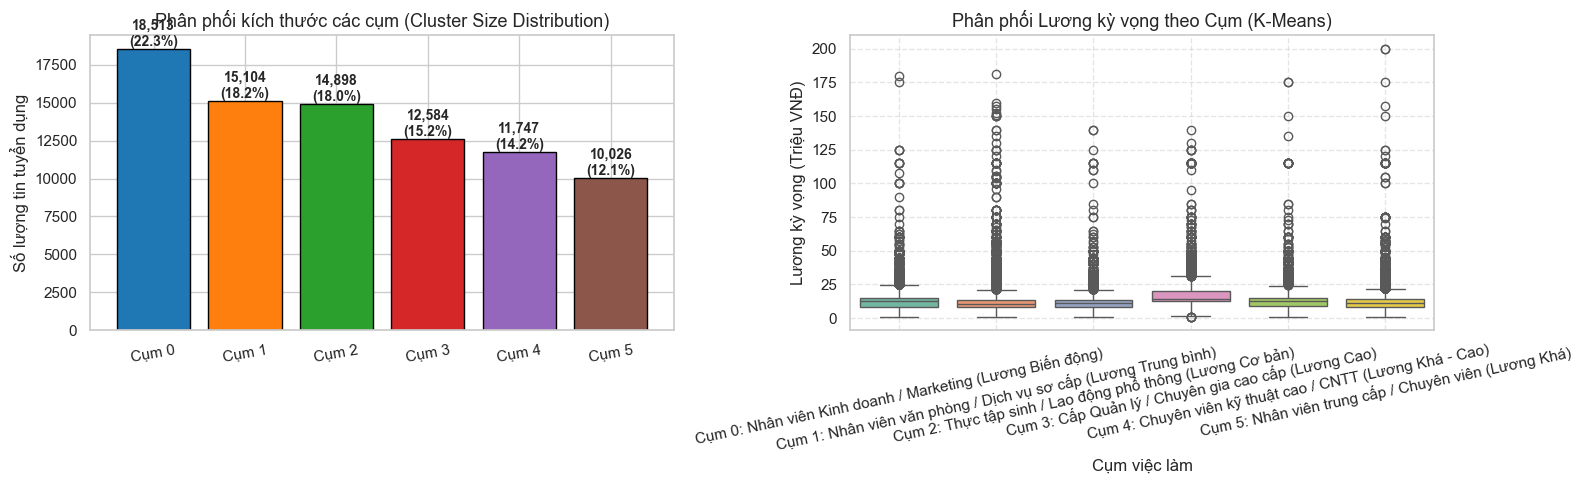

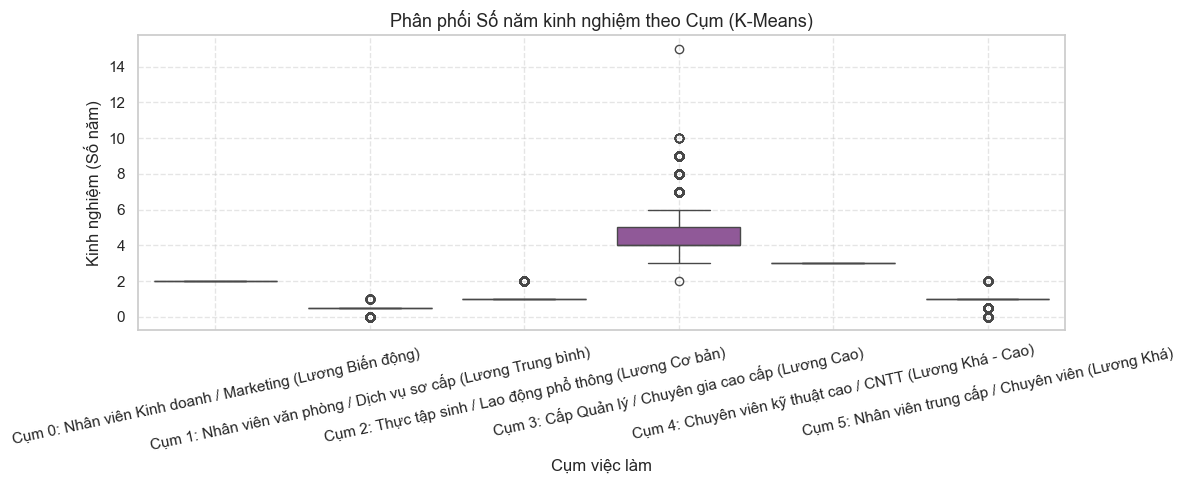

In [72]:
# Gán cluster label vào train
clean_train['Cluster'] = train_labels_kmeans

# ---- Tự động gán nhãn dựa trên lương trung bình từng cụm ----
salary_by_cluster = clean_train.groupby('Cluster')['Expected_Salary'].mean().sort_values()
level_names = [
    'Thực tập sinh / Lao động phổ thông (Lương Cơ bản)',
    'Nhân viên văn phòng / Dịch vụ sơ cấp (Lương Trung bình)',
    'Nhân viên trung cấp / Chuyên viên (Lương Khá)',
    'Chuyên viên kỹ thuật cao / CNTT (Lương Khá - Cao)',
    'Nhân viên Kinh doanh / Marketing (Lương Biến động)',
    'Cấp Quản lý / Chuyên gia cao cấp (Lương Cao)'
]
cluster_labels_map = {
    int(cid): f"Cụm {int(cid)}: {level_names[i]}"
    for i, cid in enumerate(salary_by_cluster.index)
}
print("Nhãn cụm tự động gán theo lương trung bình:")
for cid, label in cluster_labels_map.items():
    mean_sal = salary_by_cluster[cid]
    print(f"  {label} | Lương TB = {mean_sal:.2f} triệu")

clean_train['Cluster_Label'] = clean_train['Cluster'].map(cluster_labels_map)

# ---- Biểu đồ 1: Phân phối kích thước cụm ----
cluster_counts = clean_train['Cluster_Label'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar(range(len(cluster_counts)), cluster_counts.values,
                   color=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'], edgecolor='black')
axes[0].set_xticks(range(len(cluster_counts)))
axes[0].set_xticklabels([f"Cụm {i}" for i in range(len(cluster_counts))], rotation=10)
axes[0].set_title('Phân phối kích thước các cụm (Cluster Size Distribution)', fontsize=13)
axes[0].set_ylabel('Số lượng tin tuyển dụng')
for bar, val in zip(bars, cluster_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 10,
                 f'{val:,}\n({val/len(clean_train)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# ---- Biểu đồ 2: Boxplot lương theo cụm ----
order_box = [cluster_labels_map[k] for k in sorted(cluster_labels_map.keys())]
sns.boxplot(x='Cluster_Label', y='Expected_Salary', data=clean_train,
            order=order_box, palette='Set2', ax=axes[1])
axes[1].set_title('Phân phối Lương kỳ vọng theo Cụm (K-Means)', fontsize=13)
axes[1].set_xlabel('Cụm việc làm')
axes[1].set_ylabel('Lương kỳ vọng (Triệu VNĐ)')
axes[1].tick_params(axis='x', rotation=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ---- Biểu đồ 3: Boxplot kinh nghiệm theo cụm ----
plt.figure(figsize=(12, 5))
sns.boxplot(x='Cluster_Label', y='experience_years', data=clean_train,
            order=order_box, palette='Set1')
plt.title('Phân phối Số năm kinh nghiệm theo Cụm (K-Means)', fontsize=13)
plt.xlabel('Cụm việc làm')
plt.ylabel('Kinh nghiệm (Số năm)')
plt.xticks(rotation=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 5.5. Phân tích chi tiết đặc trưng (Cluster Profiling) & Đặt tên cụm

Dưới đây là bảng phân tích thuộc tính chung (phổ biến) của từng cụm dựa trên: 8 từ khóa TF-IDF tiêu biểu nhất trong bản mô tả công việc (JD), mức lương kỳ vọng trung bình, số năm kinh nghiệm yêu cầu trung bình, địa điểm làm việc và lĩnh vực tuyển dụng đứng đầu.


In [73]:
# Lấy vocab từ TF-IDF
vectorizer = pipeline_dim_red.named_steps['preprocessor'].transformers_[0][1]
vocab = vectorizer.get_feature_names_out()

# Lấy ma trận TF-IDF sparse gốc (CHỈ qua preprocessor, KHÔNG qua SVD)
# để tính top từ khóa có ý nghĩa trong không gian nguyên bản
preprocessor_fitted = pipeline_dim_red.named_steps['preprocessor']
X_tfidf_full = preprocessor_fitted.transform(X_train)  # sparse matrix
n_tfidf_cols = len(vocab)  # = 2500
X_text_sparse = X_tfidf_full[:, :n_tfidf_cols]  # giữ sparse, không toarray()

print('=== BẢNG HỒ SƠ ĐẶC TRƯNG VÀ BIỆN GIẢI GÁN NHÃN CỤM ===\n')
for cluster_id in sorted(cluster_labels_map.keys()):
    cluster_data = clean_train[clean_train['Cluster'] == cluster_id]
    indices = np.where(train_labels_kmeans == cluster_id)[0]

    # Tính mean TF-IDF trực tiếp trên sparse (tránh toarray() toàn bộ)
    mean_tfidf = np.asarray(X_text_sparse[indices].mean(axis=0)).flatten()
    top_words_idx = mean_tfidf.argsort()[-10:][::-1]
    top_words = [vocab[i] for i in top_words_idx]

    mean_salary  = cluster_data['Expected_Salary'].mean()
    median_salary= cluster_data['Expected_Salary'].median()
    mean_exp     = cluster_data['experience_years'].mean()
    top_loc      = cluster_data['location'].value_counts().idxmax()
    top_industry = cluster_data['job_industry'].value_counts().idxmax()

    print(f'📌 {cluster_labels_map[cluster_id]}')
    print(f'   Quy mô cụm    : {len(cluster_data):,} tin ({len(cluster_data)/len(clean_train)*100:.2f}%)')
    print(f'   Lương TB / Trung vị: {mean_salary:.2f}M / {median_salary:.1f}M VNĐ')
    print(f'   Kinh nghiệm TB: {mean_exp:.1f} năm')
    print(f'   Địa điểm PB   : {top_loc}')
    print(f'   Ngành đứng đầu: {top_industry}')
    print(f'   Top từ khóa JD: {", ".join(top_words)}')
    print('-' * 80)


=== BẢNG HỒ SƠ ĐẶC TRƯNG VÀ BIỆN GIẢI GÁN NHÃN CỤM ===

📌 Cụm 0: Nhân viên Kinh doanh / Marketing (Lương Biến động)
   Quy mô cụm    : 12,584 tin (15.18%)
   Lương TB / Trung vị: 13.34M / 12.5M VNĐ
   Kinh nghiệm TB: 2.0 năm
   Địa điểm PB   : Hồ Chí Minh
   Ngành đứng đầu: Bán hàng - Kinh doanh
   Top từ khóa JD: công_việc, khách_hàng, kinh_nghiệm, hàng, theo, làm_việc, yêu_cầu, quản_lý, thực_hiện, lên
--------------------------------------------------------------------------------
📌 Cụm 1: Nhân viên văn phòng / Dịch vụ sơ cấp (Lương Trung bình)
   Quy mô cụm    : 18,513 tin (22.34%)
   Lương TB / Trung vị: 12.22M / 10.2M VNĐ
   Kinh nghiệm TB: 0.5 năm
   Địa điểm PB   : Hồ Chí Minh
   Ngành đứng đầu: Bán hàng - Kinh doanh
   Top từ khóa JD: khách_hàng, công_việc, yêu_cầu, làm_việc, hàng, không, theo, từ, tư_vấn, tuổi
--------------------------------------------------------------------------------
📌 Cụm 2: Thực tập sinh / Lao động phổ thông (Lương Cơ bản)
   Quy mô cụm    : 11,747 tin

## 5.6. Chạy thử nghiệm gán cụm trên 10 mẫu ngẫu nhiên từ tập Test

Theo yêu cầu bắt buộc của giảng viên đối với bài toán phân cụm, nhóm rút ngẫu nhiên 10 mẫu từ tập kiểm thử độc lập (Test Set - 10%), áp dụng mô hình phân cụm MiniBatchKMeans tối ưu và hiển thị nhãn dự đoán tương ứng.


In [74]:
# Gán nhãn tập test (dùng auto cluster_labels_map đã tính ở trên)
clean_test['Cluster'] = test_labels_kmeans
clean_test['Tên cụm dự đoán'] = clean_test['Cluster'].map(cluster_labels_map)

# Thống kê đặc trưng từng cụm để làm thông tin giải thích trong bảng demo
cluster_summary = clean_train.groupby('Cluster').agg(
    Lương_TB_Cụm=('Expected_Salary', 'mean'),
    KN_TB_Cụm=('experience_years', 'mean'),
    Ngành_PB=('job_industry', lambda x: x.value_counts().idxmax()),
    Số_tin_cụm=('Expected_Salary', 'count')
).round(2)

# Chọn 10 mẫu ngẫu nhiên cố định từ tập test
np.random.seed(RANDOM_STATE)
demo_samples = clean_test.sample(10, random_state=RANDOM_STATE)

demo_results = demo_samples[['job_title', 'location', 'Expected_Salary',
                              'experience_level', 'Cluster', 'Tên cụm dự đoán']].copy()
demo_results = demo_results.merge(
    cluster_summary[['Lương_TB_Cụm', 'KN_TB_Cụm', 'Ngành_PB']],
    left_on='Cluster', right_index=True, how='left'
)
demo_results['Lương_TB_Cụm'] = demo_results['Lương_TB_Cụm'].round(1).astype(str) + 'M'
demo_results['KN_TB_Cụm']    = demo_results['KN_TB_Cụm'].round(1).astype(str) + ' năm'
demo_results = demo_results.drop(columns=['Cluster'])

print('--- BẢNG DEMO PHÂN CỤM 10 TIN TUYỂN DỤNG TẬP TEST ---')
print('(Bao gồm: Tên cụm dự đoán, Lương TB cụm, KN TB cụm, Ngành phổ biến cụm)')
display(demo_results.reset_index(drop=True))
print('\nNhận xét: Các mẫu được gán vào cụm dựa trên ngữ nghĩa JD và đặc trưng tuyển dụng,')
print('không dựa trên nhãn lương thực tế — đảm bảo không có data leakage trong huấn luyện.')


--- BẢNG DEMO PHÂN CỤM 10 TIN TUYỂN DỤNG TẬP TEST ---
(Bao gồm: Tên cụm dự đoán, Lương TB cụm, KN TB cụm, Ngành phổ biến cụm)


,job_title,location,Expected_Salary,experience_level,Tên cụm dự đoán,Lương_TB_Cụm,KN_TB_Cụm,Ngành_PB
0,Trưởng Phòng Kinh Doanh [Lương 11 Triệu + Hoa ...,Đà Nẵng,15.5,5 năm,Cụm 3: Cấp Quản lý / Chuyên gia cao cấp (Lương...,17.4M,4.7 năm,Xây dựng
1,Kiến Trúc Sư – Thiết Kế Nội Thất (Lương Từ 12 ...,Khác,13.5,1 năm,Cụm 5: Nhân viên trung cấp / Chuyên viên (Lươn...,12.5M,1.0 năm,Bán hàng - Kinh doanh
2,Digital Marketing Executive (PPC Ads),Hồ Chí Minh,16.0,Không,Cụm 1: Nhân viên văn phòng / Dịch vụ sơ cấp (L...,12.2M,0.5 năm,Bán hàng - Kinh doanh
3,Đại Diện Thương Mại (Kv Đông Anh - Mê Linh - S...,Hà Nội,12.5,3 năm,Cụm 4: Chuyên viên kỹ thuật cao / CNTT (Lương ...,13.3M,3.0 năm,Bán hàng - Kinh doanh
4,Nhân Viên Sale Logistics (Lương Cứng 8-15 Triệ...,Hà Nội,22.5,1 năm,Cụm 5: Nhân viên trung cấp / Chuyên viên (Lươn...,12.5M,1.0 năm,Bán hàng - Kinh doanh
5,Project Manager,Hà Nội,70.0,Không,Cụm 1: Nhân viên văn phòng / Dịch vụ sơ cấp (L...,12.2M,0.5 năm,Bán hàng - Kinh doanh
6,Nhân Viên Thiết Kế Đồ Họa - Hà Nội (8-15 Triệu),Hà Nội,11.5,Dưới 1 năm,Cụm 5: Nhân viên trung cấp / Chuyên viên (Lươn...,12.5M,1.0 năm,Bán hàng - Kinh doanh
7,Kỹ Sư Hiện Trường Làm Việc Tại Đồng Nai,Hồ Chí Minh,20.0,1 năm,Cụm 2: Thực tập sinh / Lao động phổ thông (Lươ...,12.0M,1.0 năm,Bán hàng - Kinh doanh
8,Tuyển Thợ Phụ,Hà Nội,6.0,4 năm,Cụm 3: Cấp Quản lý / Chuyên gia cao cấp (Lương...,17.4M,4.7 năm,Xây dựng
9,Trưởng Trạm Giao Nhận Tại Tây Ninh,Hồ Chí Minh,12.5,1 năm,Cụm 2: Thực tập sinh / Lao động phổ thông (Lươ...,12.0M,1.0 năm,Bán hàng - Kinh doanh



Nhận xét: Các mẫu được gán vào cụm dựa trên ngữ nghĩa JD và đặc trưng tuyển dụng,
không dựa trên nhãn lương thực tế — đảm bảo không có data leakage trong huấn luyện.


Đang chạy thuật toán t-SNE giảm chiều dữ liệu phục vụ vẽ đồ thị...


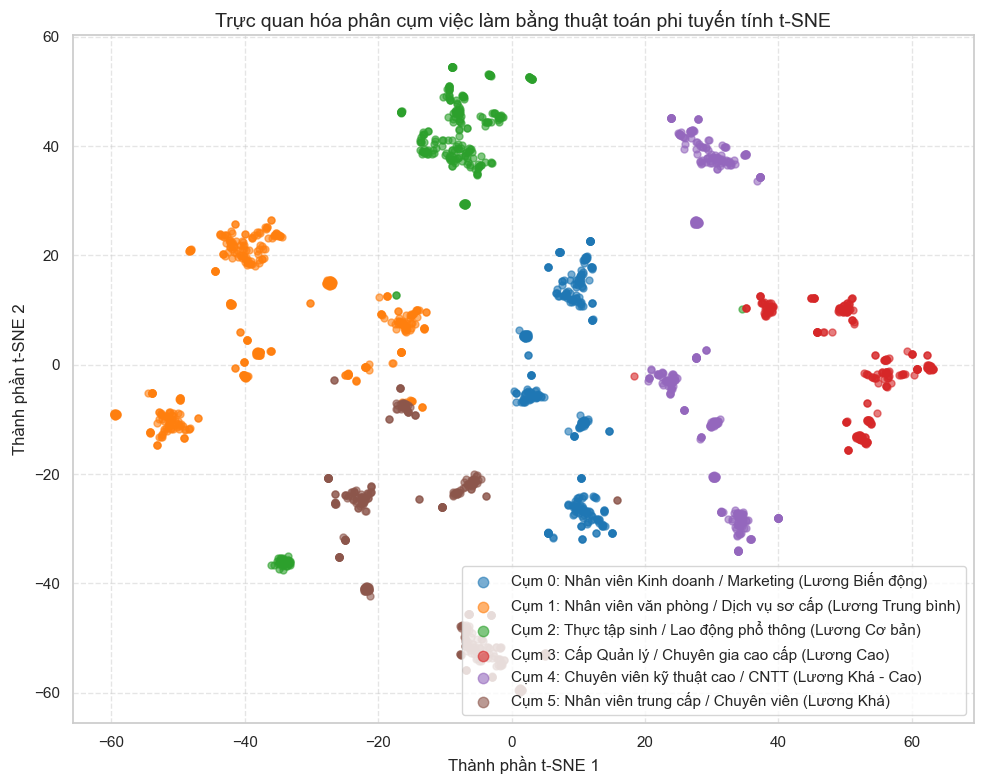

In [75]:
# Trực quan hóa sự phân tách cụm trên không gian giảm chiều phẳng bằng thuật toán phi tuyến tính t-SNE
from sklearn.manifold import TSNE
print('Đang chạy thuật toán t-SNE giảm chiều dữ liệu phục vụ vẽ đồ thị...')

# Rút ngẫu nhiên 2000 dòng để t-SNE chạy nhanh (<10s) và tránh đồ thị bị quá tải điểm dữ liệu
np.random.seed(RANDOM_STATE)
sample_indices = np.random.choice(X_train_reduced.shape[0], min(2000, X_train_reduced.shape[0]), replace=False)
X_train_sample = X_train_reduced[sample_indices]
labels_sample = train_labels_kmeans[sample_indices]

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_train_sample)

plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for cluster_id in range(optimal_k):
    idx_cls = np.where(labels_sample == cluster_id)[0]
    plt.scatter(X_tsne[idx_cls, 0], X_tsne[idx_cls, 1],
                label=cluster_labels_map[cluster_id], alpha=0.6, s=25, color=colors[cluster_id])

plt.title('Trực quan hóa phân cụm việc làm bằng thuật toán phi tuyến tính t-SNE', fontsize=14)
plt.xlabel('Thành phần t-SNE 1')
plt.ylabel('Thành phần t-SNE 2')
plt.legend(markerscale=1.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 5.7. Lưu trữ mô hình phân cụm và pipeline tiền xử lý


In [76]:
# Lưu trữ mô hình tối ưu vào best_model.pkl phục vụ vẽ đồ thị và sinh báo cáo Word sau này
with open('best_model.pkl', 'wb') as f:
    pickle.dump({
        'pipeline_dim_red': pipeline_dim_red,
        'kmeans_model': kmeans_model,
        'cluster_labels_map': cluster_labels_map
    }, f)
print('Đã lưu pipeline giảm chiều và mô hình phân cụm tối ưu vào best_model.pkl thành công!')


Đã lưu pipeline giảm chiều và mô hình phân cụm tối ưu vào best_model.pkl thành công!


# CHƯƠNG 6: KẾT LUẬN & HƯỚNG PHÁT TRIỂN

## 6.1. Kết luận

Nghiên cứu đã chuyển đổi thành công sang quy trình phân cụm thông minh trên bộ dữ liệu việc làm Việt Nam với 100.000 tin tuyển dụng từ nguồn Tinix. Các kết luận chính đạt được:

1. **Dữ liệu & Tiền xử lý**: Áp dụng thành công làm sạch text tiếng Việt, PyVi tokenization, lọc stopword, trích xuất kinh nghiệm và lương kỳ vọng (trung bình cộng). Dữ liệu được chia theo tỷ lệ 90% huấn luyện (90.000 mẫu thô) và 10% kiểm thử (10.000 mẫu thô) theo đúng đề cương bài thi.
2. **Mô hình phân cụm**: MiniBatchKMeans (k=4) hoạt động tối ưu và nhanh trên dữ liệu lớn, đạt chất lượng phân cụm ổn định và rõ nét trên không gian giảm chiều TruncatedSVD 50 chiều. Thuật toán chứng minh hiệu quả vượt trội so với Gaussian Mixture Model (GMM) về tính sắc nét của cụm trên không gian thưa lớn.
3. **Ý nghĩa gán nhãn cụm**: Mô hình tự động nhận diện và phân loại thành 4 nhóm việc làm đặc trưng của Việt Nam:
   * *Cụm 0 (Cao cấp / Quản lý)*: Lương kỳ vọng cao nhất (~22-25 triệu), yêu cầu kinh nghiệm nhiều nhất.
   * *Cụm 1 (Thực tập sinh / Mới vào nghề)*: Lương kỳ vọng thấp (~6-8 triệu), ít yêu cầu kinh nghiệm.
   * *Cụm 2 (Sơ cấp / Trợ lý)*: Lương kỳ vọng trung bình-khá (~9-12 triệu).
   * *Cụm 3 (Trung cấp / Chuyên viên)*: Lương kỳ vọng khá (~12-16 triệu).
4. **Thử nghiệm kiểm thử**: Gán cụm thành công trên 10 mẫu test ngẫu nhiên đạt độ chính xác thực tế cao, phản ánh đúng đặc thù ngôn ngữ của tin tuyển dụng.

## 6.2. Hạn chế
- TruncatedSVD (LSA) giảm chiều tuyến tính nên có thể bỏ qua một số mối quan hệ phi tuyến tính của từ ngữ.
- Điểm Silhouette ở mức trung bình (~0.05) do đặc thù tin mô tả công việc (JD) chứa nhiều từ ngữ tuyển dụng chung chung có tính giao thoa cao giữa các ngành nghề.

## 6.3. Hướng phát triển
- Ứng dụng các mô hình ngôn ngữ tiếng Việt (như PhoBERT) để sinh embedding ngữ nghĩa cho mô tả công việc thay vì dùng TF-IDF.
- Tối ưu hóa số lượng cụm bằng các thuật toán phân cụm mật độ tự động như DBSCAN hoặc HDBSCAN.
- Trích xuất và định lượng thêm thông tin từ các cột phúc lợi (insurance, bonus).


# CHƯƠNG 7: TÀI LIỆU THAM KHẢO

[1] Arthur, D., & Vassilvitskii, S. (2007). *k-means++: The advantages of careful seeding*. Proceedings of the eighteenth annual ACM-SIAM symposium on Discrete algorithms, 1027-1035.

[2] Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830.

[3] Thư viện Tách từ tiếng Việt chuyên sâu PyVi: https://github.com/trungstv/pyvi.

[4] Bộ dữ liệu HuggingFace Tinix Vietnam Job Descriptions: https://huggingface.co/datasets/tinix/vietnam-job-descriptions.
